# MT²-CSD Analysis — LLM Stance Detection

Evaluates models on the **MT²-CSD** test set (2,371 documents, 3 classes: FAVOR / AGAINST / NONE).  
Targets: **Bitcoin, Tesla, SpaceX, Biden, Trump** (Post-T excluded — not in our test set).

**Primary metric**: 3-class Macro F1 — consistent with EZStance / SemEval analysis in this paper.  
**Secondary metric**: F_avg = (F_favor + F_against) / 2 — paper metric, for comparison against Table IX baselines.

**Paper baselines** (Table IX, *"Only considering individual posts/comments"* section, 5-target avg excluding Post-T):

| Method | Bitcoin | Tesla | SpaceX | Biden | Trump | 5T Avg |
|--------|---------|-------|--------|-------|-------|--------|
| TTS (best) | 50.88 | 43.85 | 47.50 | 29.00 | 42.10 | **42.67** |
| KPT        | 50.34 | 43.11 | 47.47 | 28.90 | 41.87 | 42.34 |
| BERT       | 50.99 | 43.85 | 45.88 | 26.65 | 42.45 | 41.96 |

> 3-class F1 baselines from the paper are **not available** (paper only reports 2-class F_avg). Conversation-history baselines excluded — our models use individual posts/comments only.  
> F_avg is computed **per target first, then macro-averaged across 5 targets** — matching the paper's methodology.

## Step 1: Imports

In [299]:
import os
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

## Step 2: Config

In [300]:
_candidates = [Path("../data_out/stance/mtcsd_test_results"), Path("data_out/stance/mtcsd_test_results")]
RESULTS_DIR = next(p for p in _candidates if p.exists())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

_gold_candidates = [Path("../data_in/mtcsd/mtcsd_test.csv"), Path("data_in/mtcsd/mtcsd_test.csv")]
GOLD_PATH = next(p for p in _gold_candidates if p.exists())

PREFIX  = "GenAIStanceOneShot_2371_mtcsd_test_"
CLASSES = ["FAVOR", "AGAINST", "NONE"]
TARGET_ORDER = ["Bitcoin", "Tesla", "SpaceX", "Biden", "Trump"]

PROMPT_ORDER = [
    "default_no_label_definitions", "default", "task_definition",
    "question", "cot", "task_definition_scale",
    "few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15",
]
PROMPT_LABELS = {
    "default_no_label_definitions": "No-def",  "default": "Default",
    "task_definition": "Task-def",              "question": "Question",
    "cot": "CoT",                               "task_definition_scale": "Scale",
    "few_shot_3": "3R",  "few_shot_6": "6R",  "few_shot_9": "9R",
    "few_shot_12": "12R", "few_shot_15": "15R",
}
ZERO_SHOT  = ["default_no_label_definitions","default","task_definition","question","cot","task_definition_scale"]
RANDOM_ICL = ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"]

CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

# Paper baselines — individual section, F_avg, 5-target avg (Post-T excluded)
PAPER_FAVG = {
    "TTS (best indiv.)": 42.67 / 100,
    "KPT":               42.34 / 100,
    "BERT (indiv.)":     41.96 / 100,
}
PAPER_PER_TARGET = {
    "TTS":  {"Bitcoin":50.88/100,"Tesla":43.85/100,"SpaceX":47.50/100,"Biden":29.00/100,"Trump":42.10/100},
    "KPT":  {"Bitcoin":50.34/100,"Tesla":43.11/100,"SpaceX":47.47/100,"Biden":28.90/100,"Trump":41.87/100},
    "BERT": {"Bitcoin":50.99/100,"Tesla":43.85/100,"SpaceX":45.88/100,"Biden":26.65/100,"Trump":42.45/100},
}

GOLD_DIST = {"FAVOR": 466/2371, "AGAINST": 724/2371, "NONE": 1181/2371}

CANON_MAP = {"PRO": "FAVOR", "NEUTRAL": "NONE", "UNCLEAR": "NONE"}
def canon(s):
    s = str(s).upper().strip()
    return CANON_MAP.get(s, s)

print("Targets:", TARGET_ORDER)
print("Gold dist:", {k: f"{v:.3f}" for k,v in GOLD_DIST.items()})

RESULTS_DIR: /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/mtcsd_test_results
Targets: ['Bitcoin', 'Tesla', 'SpaceX', 'Biden', 'Trump']
Gold dist: {'FAVOR': '0.197', 'AGAINST': '0.305', 'NONE': '0.498'}


## Step 2b: Gold Label Distribution

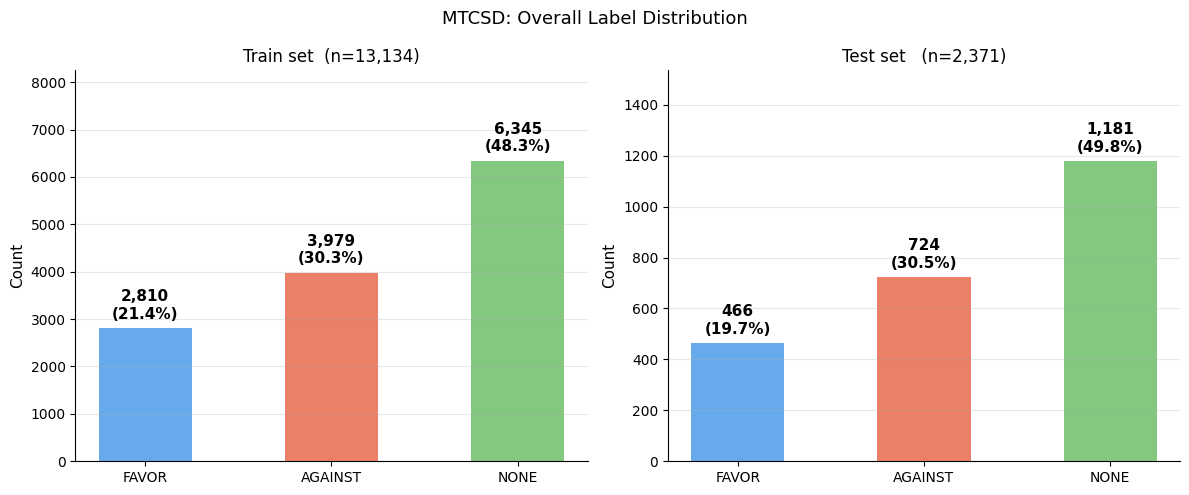

In [301]:
_tr = pd.read_csv("../data_in/mtcsd/mtcsd_train.csv")
_te = pd.read_csv("../data_in/mtcsd/mtcsd_test.csv")
_LBLS  = ["FAVOR", "AGAINST", "NONE"]
_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

def _lc(df):
    vc = df["stance_label_original"].str.upper().str.strip().value_counts()
    return {l: vc.get(l, 0) for l in _LBLS}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MTCSD: Overall Label Distribution", fontsize=13)
for ax, (counts, title) in zip(axes, [
        (_lc(_tr), f"Train set  (n={len(_tr):,})"),
        (_lc(_te), f"Test set   (n={len(_te):,})")]):
    total = sum(counts.values())
    vals  = [counts[l] for l in _LBLS]
    bars  = ax.bar(_LBLS, vals, color=[_COLORS[l] for l in _LBLS], alpha=0.85, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f"{v:,}\n({v/total:.1%})", ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(vals)*1.3)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Step 3: Load LLM Results

- **3-class Macro F1** — primary metric (global, consistent with EZStance / SemEval)  
- **F_avg** — paper metric: per-target (F_favor+F_against)/2, then macro-averaged across 5 targets

In [302]:
llm_rows = []

for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    stem  = folder.replace(PREFIX, "")
    parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2:
        continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df["original_stance"]  = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue

    yt, yp = df["original_stance"].tolist(), df["predicted_stance"].tolist()

    # 3-class Macro F1 (primary — global)
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yp, labels=CLASSES, zero_division=0)
    macro_f1 = f1.mean()

    # F_avg — per-target then average (paper methodology)
    per_tgt_favg = []
    for t in TARGET_ORDER:
        sub = df[df["query"].astype(str).str.strip() == t]
        if len(sub) == 0:
            continue
        _, _, ft, _ = precision_recall_fscore_support(
            sub["original_stance"].tolist(), sub["predicted_stance"].tolist(),
            labels=CLASSES, zero_division=0)
        per_tgt_favg.append((ft[0] + ft[1]) / 2)
    f_avg = np.mean(per_tgt_favg) if per_tgt_favg else float("nan")

    vc = pd.Series(yp).value_counts()
    llm_rows.append({
        "model": model, "prompt": prompt,
        "3class_macro_f1": macro_f1, "f_avg": f_avg,
        "f_favor":   f1[0], "f_against": f1[1], "f_none": f1[2],
        "p_favor":  prec[0], "p_against": prec[1], "p_none": prec[2],
        "r_favor":   rec[0], "r_against":  rec[1], "r_none":  rec[2],
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
        "n_valid": len(df),
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Loaded {len(llm_df)} rows | {llm_df['model'].nunique()} models")
print("Models:", sorted(llm_df["model"].unique()))
llm_df[["model","prompt","3class_macro_f1","f_avg","f_favor","f_against","f_none"]].head(6)

Loaded 154 rows | 14 models
Models: ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']


,model,prompt,3class_macro_f1,f_avg,f_favor,f_against,f_none
0,DeepSeek-R1-Distill-Llama-8B,cot,0.556782,0.453475,0.477679,0.541056,0.651613
1,DeepSeek-R1-Distill-Llama-8B,default,0.519591,0.403783,0.441978,0.459750,0.657045
2,DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,0.524551,0.427189,0.446208,0.529878,0.597566
3,DeepSeek-R1-Distill-Llama-8B,few_shot_12,0.552651,0.430166,0.476836,0.510878,0.670237
4,DeepSeek-R1-Distill-Llama-8B,few_shot_15,0.545297,0.430840,0.445961,0.517725,0.672205
5,DeepSeek-R1-Distill-Llama-8B,few_shot_3,0.540769,0.405495,0.444976,0.492679,0.684652


## Step 4: Helper — ordered model list

In [303]:
def _ordered_models(df, by="3class_macro_f1"):
    return df.groupby("model")[by].mean().sort_values(ascending=False).index.tolist()

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS[p] for p in available_prompts]

# Separator x-position between zero-shot and ICL
if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    ICL_SEP = (available_prompts.index("task_definition_scale") +
               available_prompts.index("few_shot_3")) / 2
else:
    ICL_SEP = None

def add_icl_sep(ax):
    if ICL_SEP is None:
        return
    ax.axvline(ICL_SEP, color="grey", linestyle=":", linewidth=1)
    bounds = [-0.5, ICL_SEP, len(available_prompts) - 0.5]
    for gi, lbl in enumerate(["Zero-shot", "Random ICL"]):
        mid = (bounds[gi] + bounds[gi+1]) / 2
        ax.text(mid, -0.08, lbl, ha="center", fontsize=7.5, color="grey",
                transform=ax.get_xaxis_transform())

print("Prompts:", available_prompts)
print("ICL separator at x =", ICL_SEP)

Prompts: ['default_no_label_definitions', 'default', 'task_definition', 'question', 'cot', 'task_definition_scale', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15']
ICL separator at x = 5.5


## Step 5: Chart A — 3-class Macro F1 by Prompt (Primary Metric)

No paper baseline available for 3-class F1 on MT²-CSD — our models only.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19274/2271945512.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))


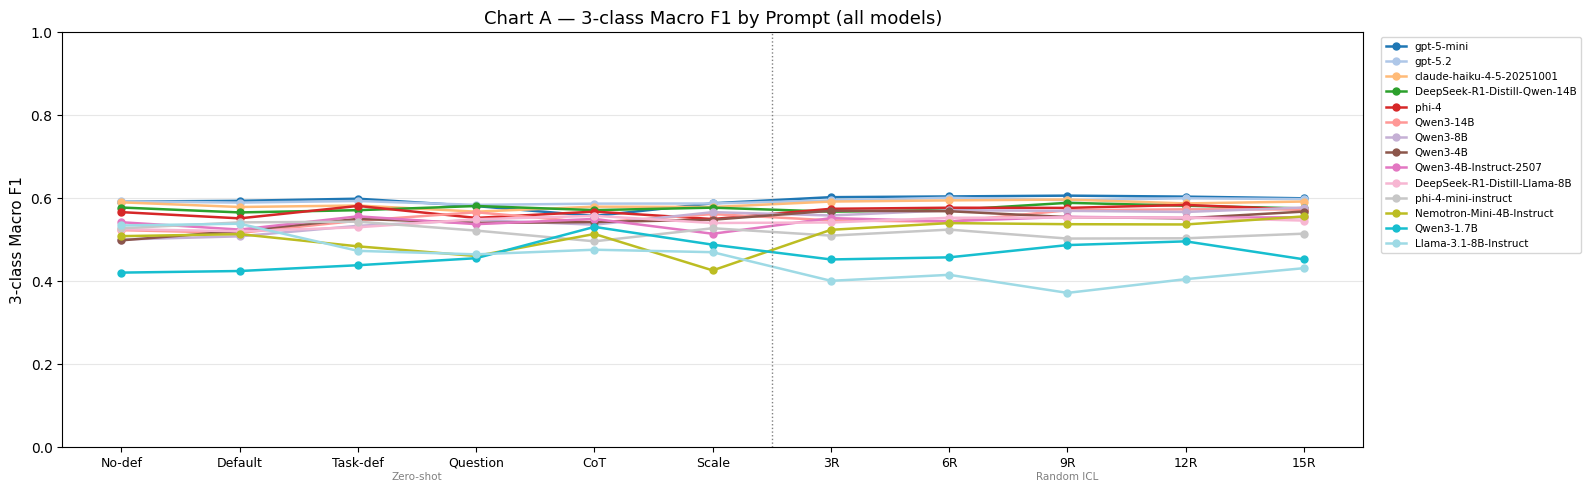

In [304]:
models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))

fig, ax = plt.subplots(figsize=(max(16, len(available_prompts) * 1.2), 5))
for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y   = [mdf.loc[p, "3class_macro_f1"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5, label=model, color=cmap(i))

add_icl_sep(ax)
ax.set_ylim(0, 1)
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Chart A — 3-class Macro F1 by Prompt (all models)", fontsize=13)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 6: Chart B — F_avg by Prompt vs Paper Baselines (Paper Metric)

F_avg = (F_favor + F_against) / 2, computed per target then macro-averaged. Paper baselines from Table IX individual section, 5-target avg.

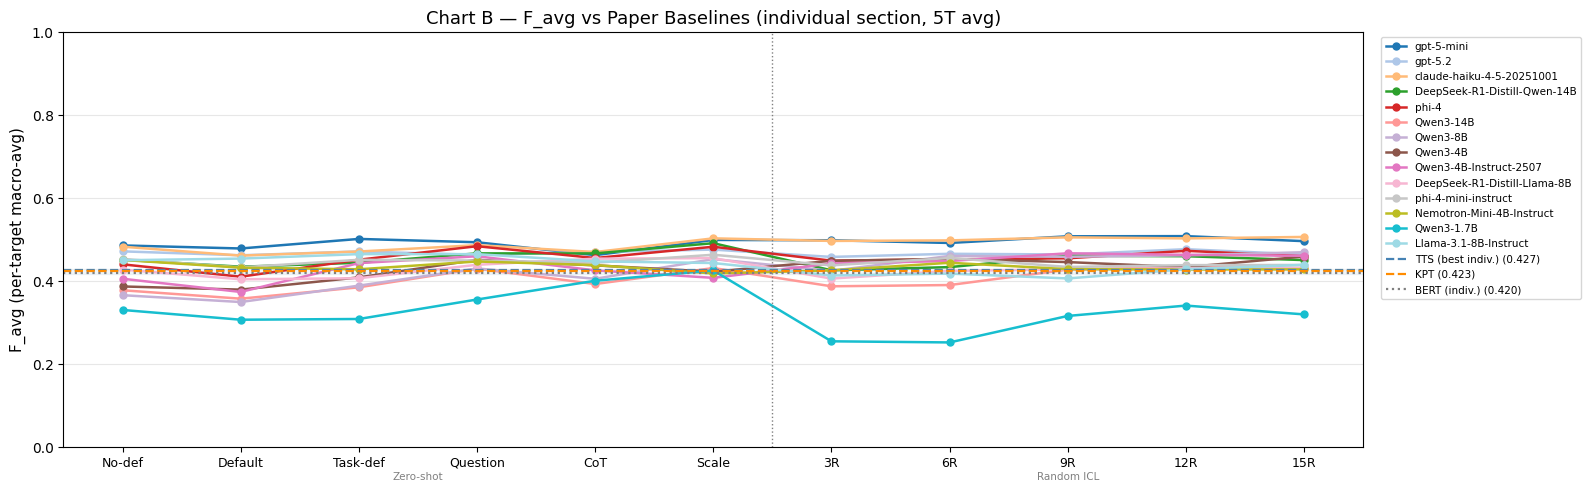

In [305]:
fig, ax = plt.subplots(figsize=(max(16, len(available_prompts) * 1.2), 5))
for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y   = [mdf.loc[p, "f_avg"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5, label=model, color=cmap(i))

bl_styles = [
    ("TTS (best indiv.)", "steelblue", "--"),
    ("KPT",               "darkorange","--"),
    ("BERT (indiv.)",     "grey",      ":"),
]
for name, col, ls in bl_styles:
    val = PAPER_FAVG[name]
    ax.axhline(val, color=col, linestyle=ls, linewidth=1.6, label=f"{name} ({val:.3f})")

vals = list(PAPER_FAVG.values())
ax.axhspan(min(vals)-0.003, max(vals)+0.003, alpha=0.07, color="steelblue")

add_icl_sep(ax)
ax.set_ylim(0, 1)
ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("F_avg (per-target macro-avg)", fontsize=11)
ax.set_title("Chart B — F_avg vs Paper Baselines (individual section, 5T avg)", fontsize=13)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 7: Numerical Summary — 3-class F1 and F_avg

In [306]:
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f3    =("3class_macro_f1","mean"), best_f3    =("3class_macro_f1","max"),
        std_f3     =("3class_macro_f1","std"),
        mean_f_avg =("f_avg",          "mean"), best_f_avg =("f_avg",          "max"),
        mean_ffav  =("f_favor",        "mean"), mean_fagn  =("f_against",      "mean"),
        mean_fnon  =("f_none",         "mean"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)

hdr = f"{'Model':<38} {'F3 mean':>8} {'F3 best':>8} {'F3 std':>7} {'Favg mean':>10} {'Favg best':>10} {'F-FAV':>7} {'F-AGN':>7} {'F-NON':>7}"
print(hdr); print("─"*len(hdr))
for _, r in summary.iterrows():
    print(f"{r['model']:<38} {r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {r['std_f3']:>7.4f} "
          f"{r['mean_f_avg']:>10.4f} {r['best_f_avg']:>10.4f} "
          f"{r['mean_ffav']:>7.4f} {r['mean_fagn']:>7.4f} {r['mean_fnon']:>7.4f}")
print("─"*len(hdr))
print("\nPaper F_avg baselines (individual section, 5T avg):")
for k,v in PAPER_FAVG.items(): print(f"  {k:<30} {v:.4f}")

Model                                   F3 mean  F3 best  F3 std  Favg mean  Favg best   F-FAV   F-AGN   F-NON
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
gpt-5-mini                               0.5926   0.6054  0.0143     0.4926     0.5078  0.4920  0.6187  0.6671
gpt-5.2                                  0.5921   0.6003  0.0056     0.4671     0.4764  0.4749  0.6137  0.6878
claude-haiku-4-5-20251001                0.5847   0.5960  0.0088     0.4890     0.5059  0.5108  0.6002  0.6431
DeepSeek-R1-Distill-Qwen-14B             0.5746   0.5881  0.0069     0.4528     0.4908  0.4788  0.5652  0.6798
phi-4                                    0.5677   0.5830  0.0122     0.4553     0.4835  0.4582  0.5820  0.6630
Qwen3-14B                                0.5502   0.5724  0.0197     0.4036     0.4335  0.4360  0.5126  0.7021
Qwen3-8B                                 0.5479   0.5768  0.0262     0.4239     0.4690  0.4384  0.5303  0.6749
Q

## Step 8: Per-class Precision / Recall / F1 — by Prompt

3 × 3 grid: rows = FAVOR / AGAINST / NONE, columns = Precision / Recall / F1.

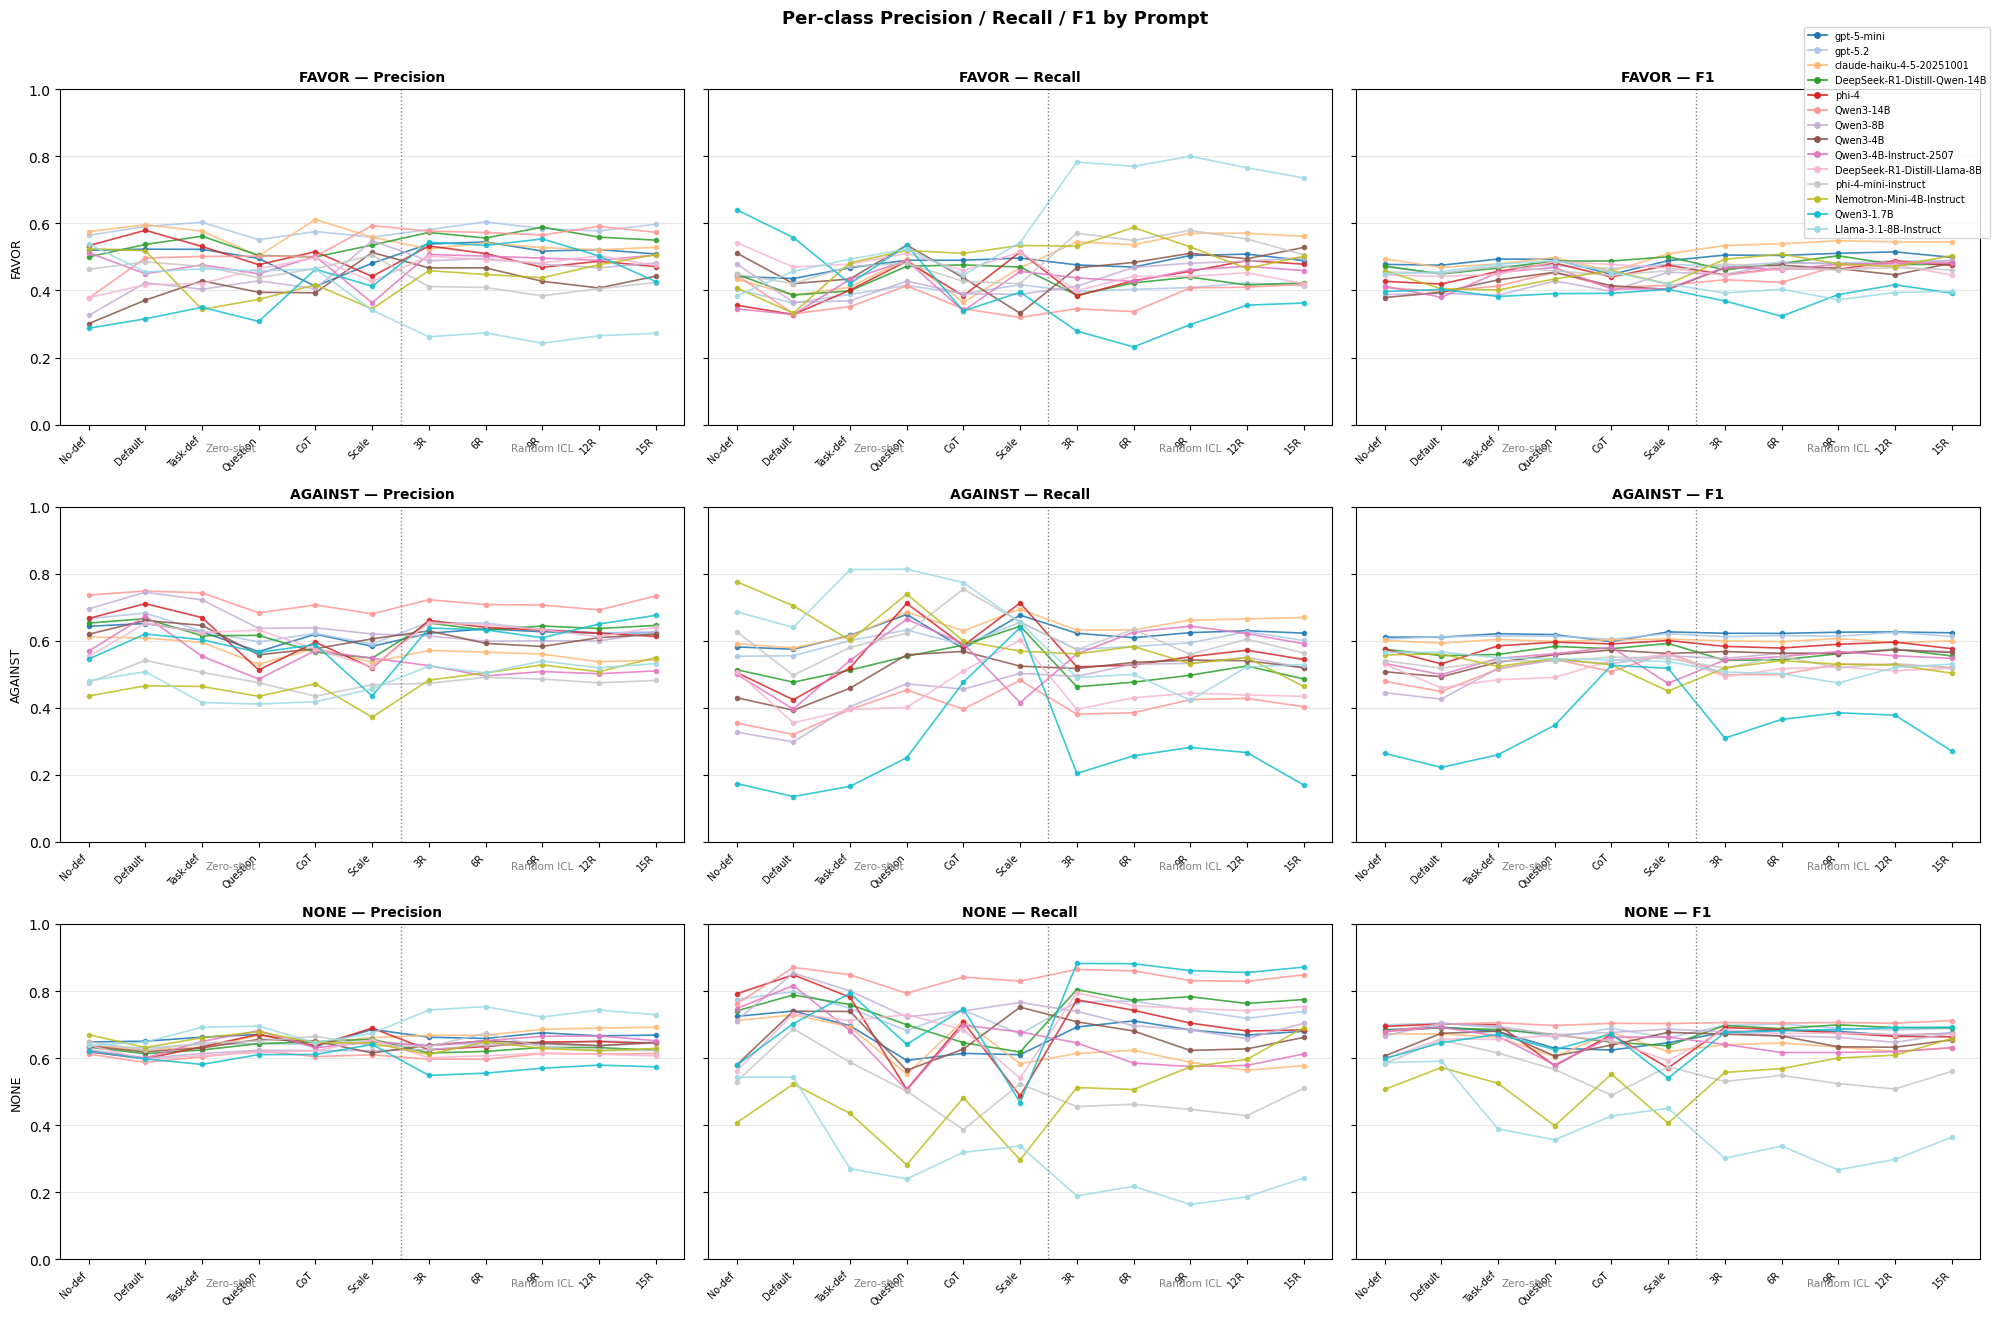

In [307]:
METRICS = [("p","Precision"),("r","Recall"),("f","F1")]
fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (mk, ml) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{mk}_{cls.lower()}"
        for i, model in enumerate(models):
            mdf = llm_df[llm_df["model"]==model].set_index("prompt")
            y   = [mdf.loc[p, col_name] if p in mdf.index else float("nan") for p in available_prompts]
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=model, color=cmap(i), alpha=0.85)
        add_icl_sep(ax)
        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {ml}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0: ax.set_ylabel(cls, fontsize=9)

handles = [mlines.Line2D([],[],color=cmap(i),marker="o",linewidth=1.2,markersize=4,label=m)
           for i,m in enumerate(models)]
fig.legend(handles=handles, fontsize=7, loc="upper right", bbox_to_anchor=(1.0,1.0))
fig.suptitle("Per-class Precision / Recall / F1 by Prompt", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## Step 9: Per-class F1 — Model Comparison (mean ± std across prompts)

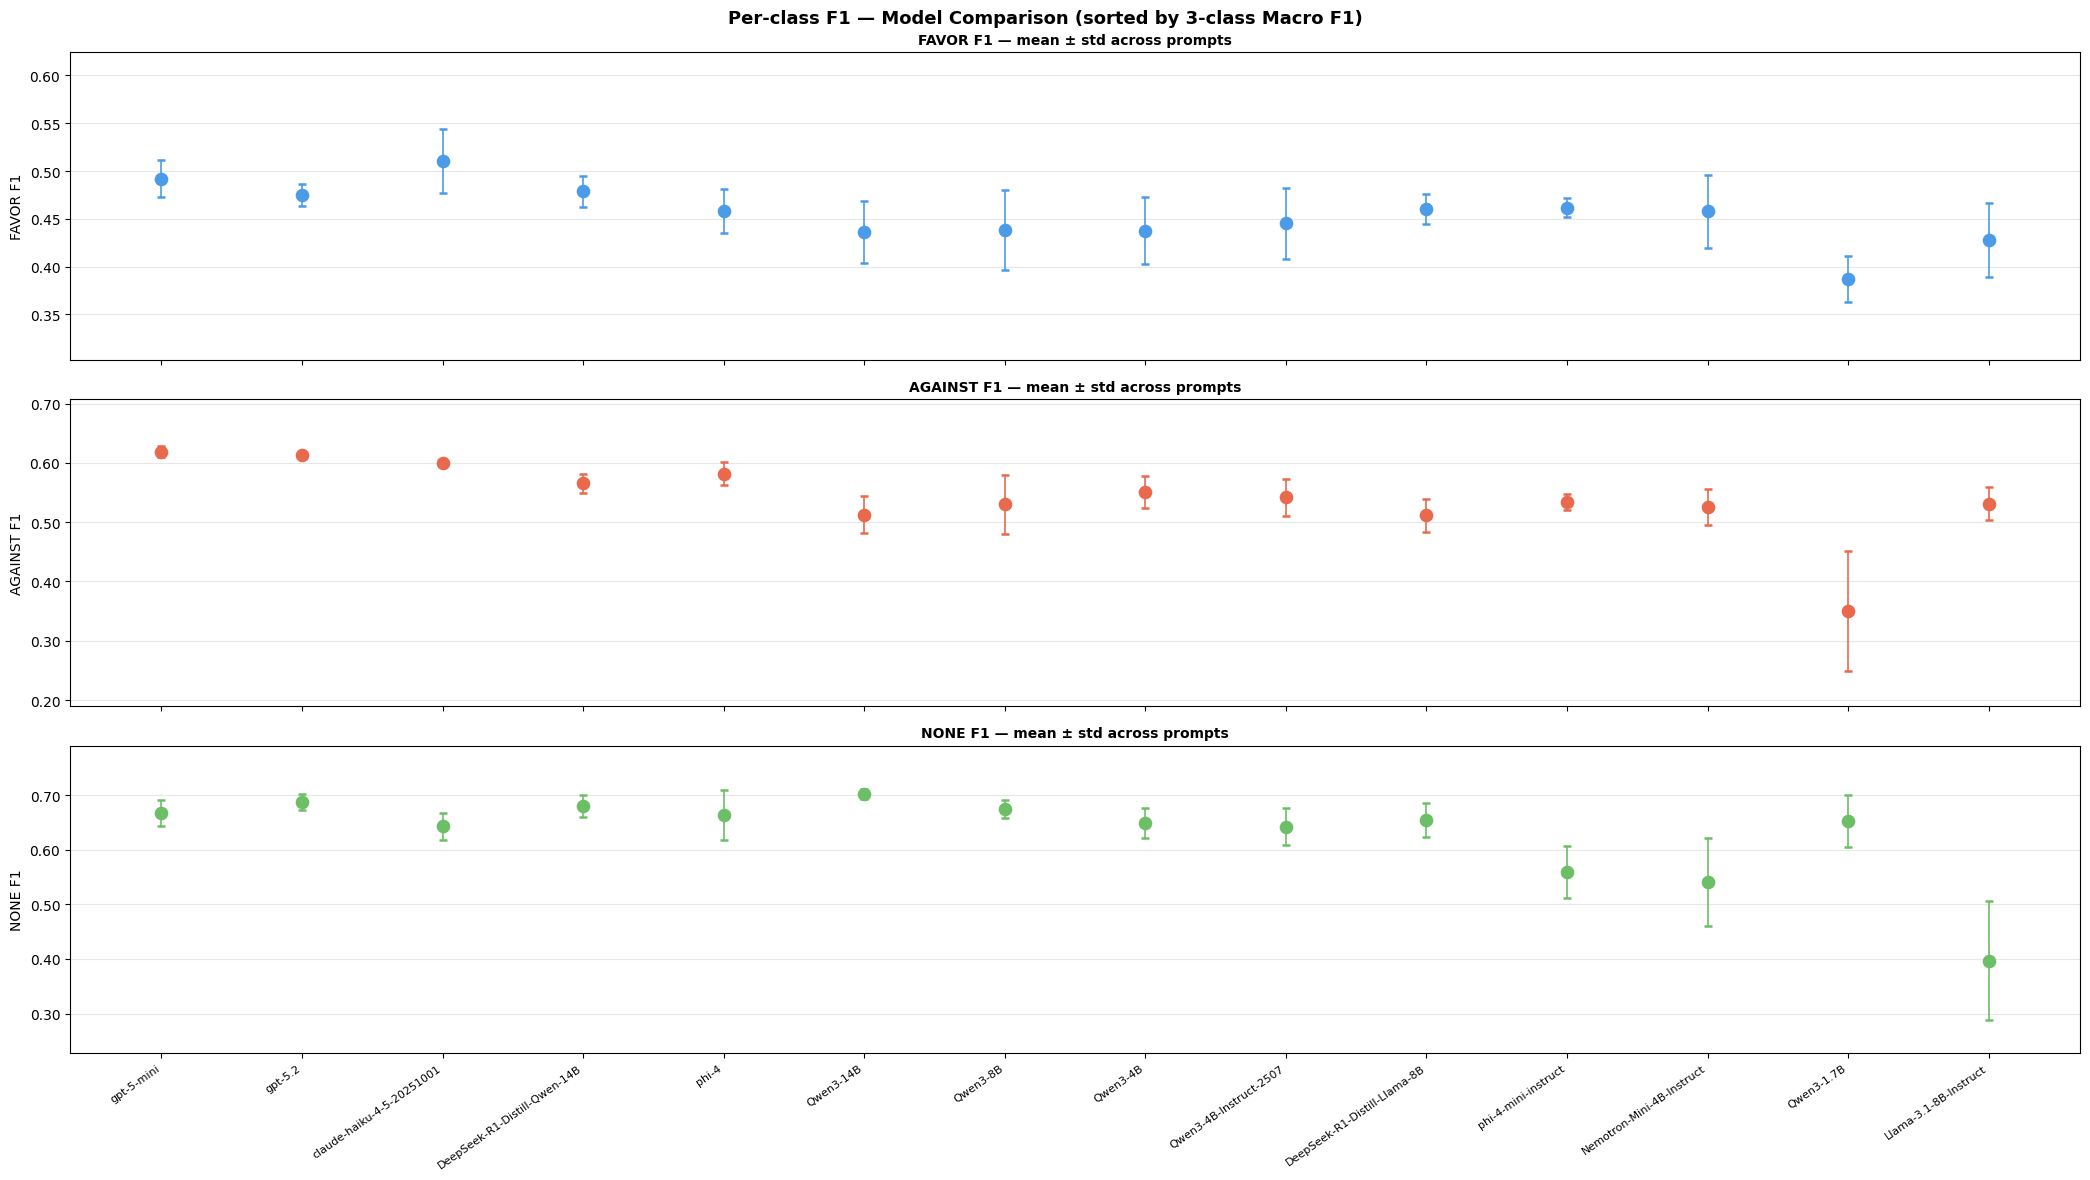

In [308]:
model_order = _ordered_models(llm_df)
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(model_order)*1.5), 12), sharex=True)
for row_idx, cls in enumerate(CLASSES):
    ax    = axes[row_idx]
    col   = f"f_{cls.lower()}"
    color = CLASS_COLORS[cls]
    means = np.array([llm_df[llm_df["model"]==m][col].mean() for m in model_order])
    stds  = np.array([llm_df[llm_df["model"]==m][col].std()  for m in model_order])
    for i,(mv,sv) in enumerate(zip(means,stds)):
        ax.errorbar(x[i], mv, yerr=sv, fmt="o", markersize=8,
                    color=color, markeredgecolor=color, markeredgewidth=1.8,
                    ecolor=color, elinewidth=1.2, capsize=3, zorder=3)
    ax.set_ylabel(f"{cls} F1", fontsize=10)
    lo = max(0,(means-stds).min()-0.06); hi = min(1,(means+stds).max()+0.08)
    ax.set_ylim(lo, hi)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — mean ± std across prompts", fontsize=10, fontweight="bold")

axes[-1].set_xticks(x); axes[-1].set_xticklabels(model_order, fontsize=8, rotation=35, ha="right")
fig.suptitle("Per-class F1 — Model Comparison (sorted by 3-class Macro F1)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 10: Precision vs Recall Scatter — per class

One panel per class. Each point = one model × prompt combination.

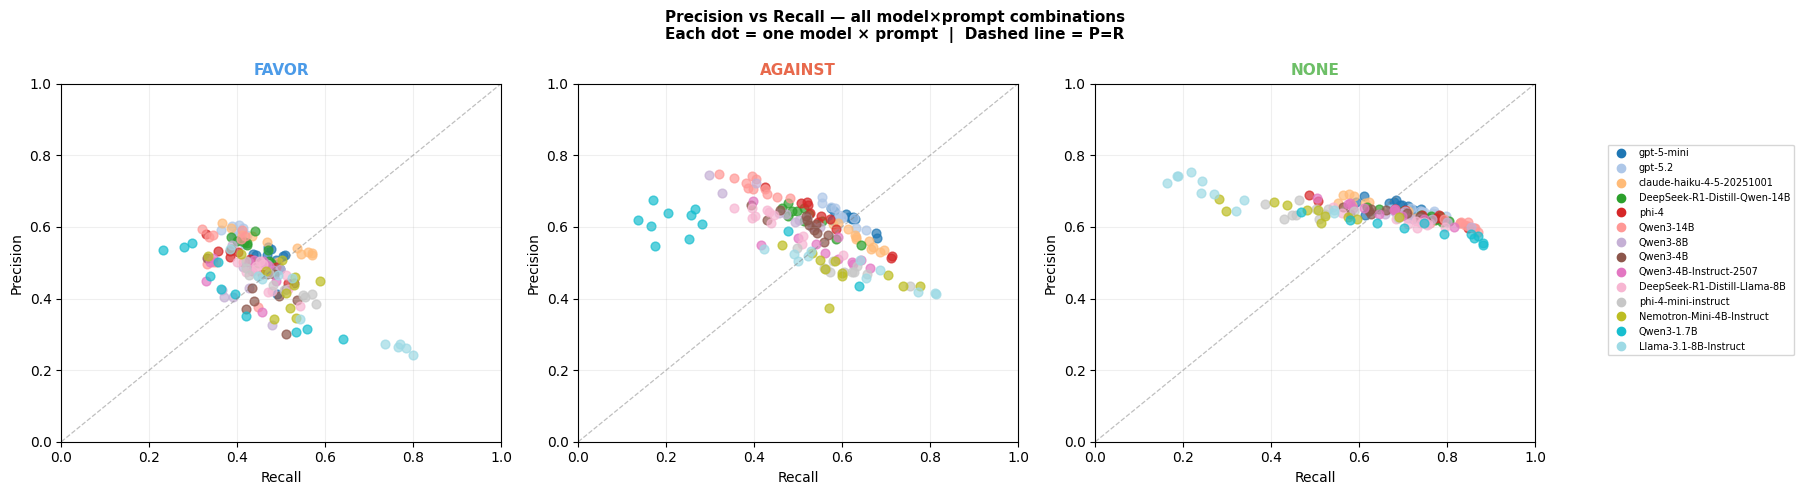

In [309]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for col_idx, cls in enumerate(CLASSES):
    ax = axes[col_idx]
    for i, model in enumerate(model_order):
        mdf = llm_df[llm_df["model"] == model]
        ax.scatter(mdf[f"r_{cls.lower()}"], mdf[f"p_{cls.lower()}"],
                   color=cmap(i), alpha=0.7, s=40, label=model)
    ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=0.9, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(cls, fontsize=11, fontweight="bold", color=CLASS_COLORS[cls])
    ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", color=cmap(i), linewidth=0, markersize=6, label=m)
           for i, m in enumerate(model_order)]
fig.legend(handles=handles, fontsize=7, loc="center right", bbox_to_anchor=(1.0, 0.5), borderaxespad=0.1)
fig.suptitle("Precision vs Recall — all model×prompt combinations\nEach dot = one model × prompt  |  Dashed line = P=R",
             fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0, 0, 0.87, 1])
plt.show()

## Step 11: Predicted vs Gold Distribution

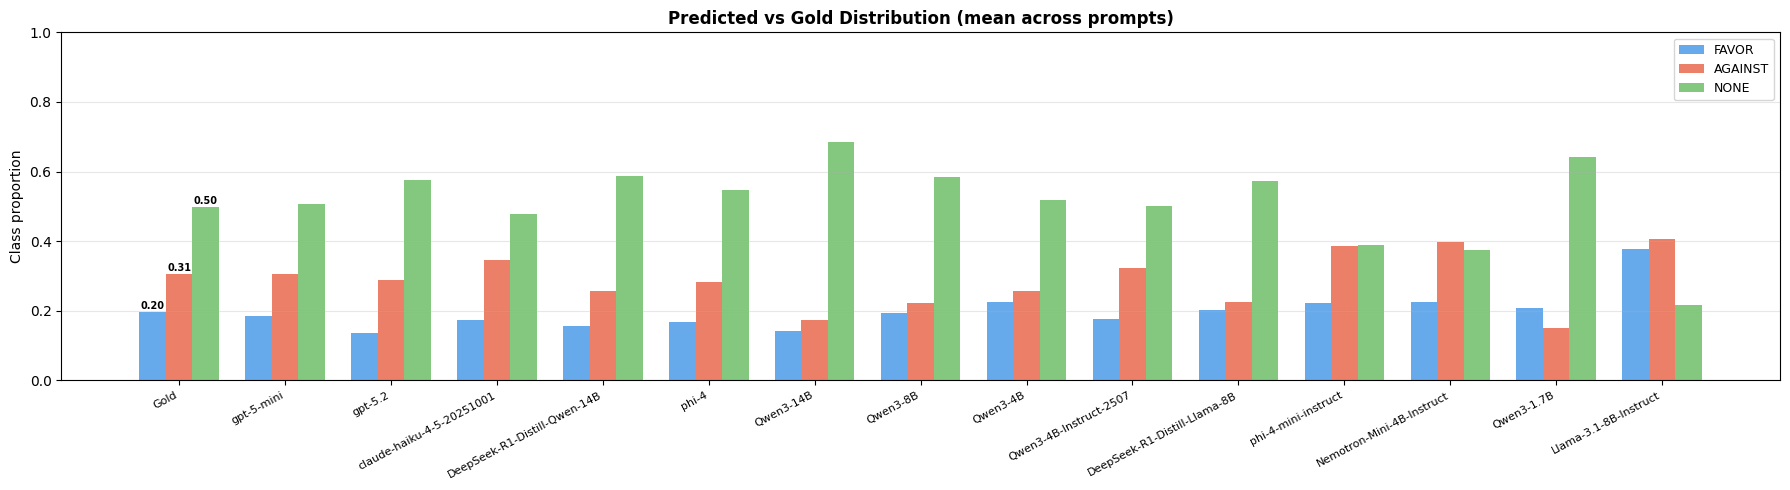

In [310]:
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100: continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({"model":model,"prompt":prompt,
                      "pred_favor":vc.get("FAVOR",0),"pred_against":vc.get("AGAINST",0),"pred_none":vc.get("NONE",0)})

dist_df   = pd.DataFrame(dist_rows)
dist_mean = dist_df.groupby("model")[["pred_favor","pred_against","pred_none"]].mean().reset_index()
gold_row  = pd.DataFrame([{"model":"Gold","pred_favor":GOLD_DIST["FAVOR"],
                            "pred_against":GOLD_DIST["AGAINST"],"pred_none":GOLD_DIST["NONE"]}])
all_order = ["Gold"] + model_order
dist_full = pd.concat([gold_row, dist_mean], ignore_index=True).set_index("model").reindex(all_order)

x_d = np.arange(len(all_order)); bw = 0.25
fig, ax = plt.subplots(figsize=(max(10, len(all_order)*1.2), 5))
for ci, cls in enumerate(CLASSES):
    vals = dist_full[f"pred_{cls.lower()}"].fillna(0).values
    ax.bar(x_d + (ci-1)*bw, vals, width=bw, color=CLASS_COLORS[cls], label=cls, alpha=0.85)
    for bi,v in enumerate(vals):
        if bi==0: ax.text(x_d[bi]+(ci-1)*bw, v+0.008, f"{v:.2f}", ha="center", fontsize=7, fontweight="bold")
ax.set_xticks(x_d); ax.set_xticklabels(all_order, fontsize=8, rotation=28, ha="right")
ax.set_ylim(0,1); ax.set_ylabel("Class proportion"); ax.legend(fontsize=9)
ax.set_title("Predicted vs Gold Distribution (mean across prompts)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 12: Confusion Transition Heatmap

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19274/482550820.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


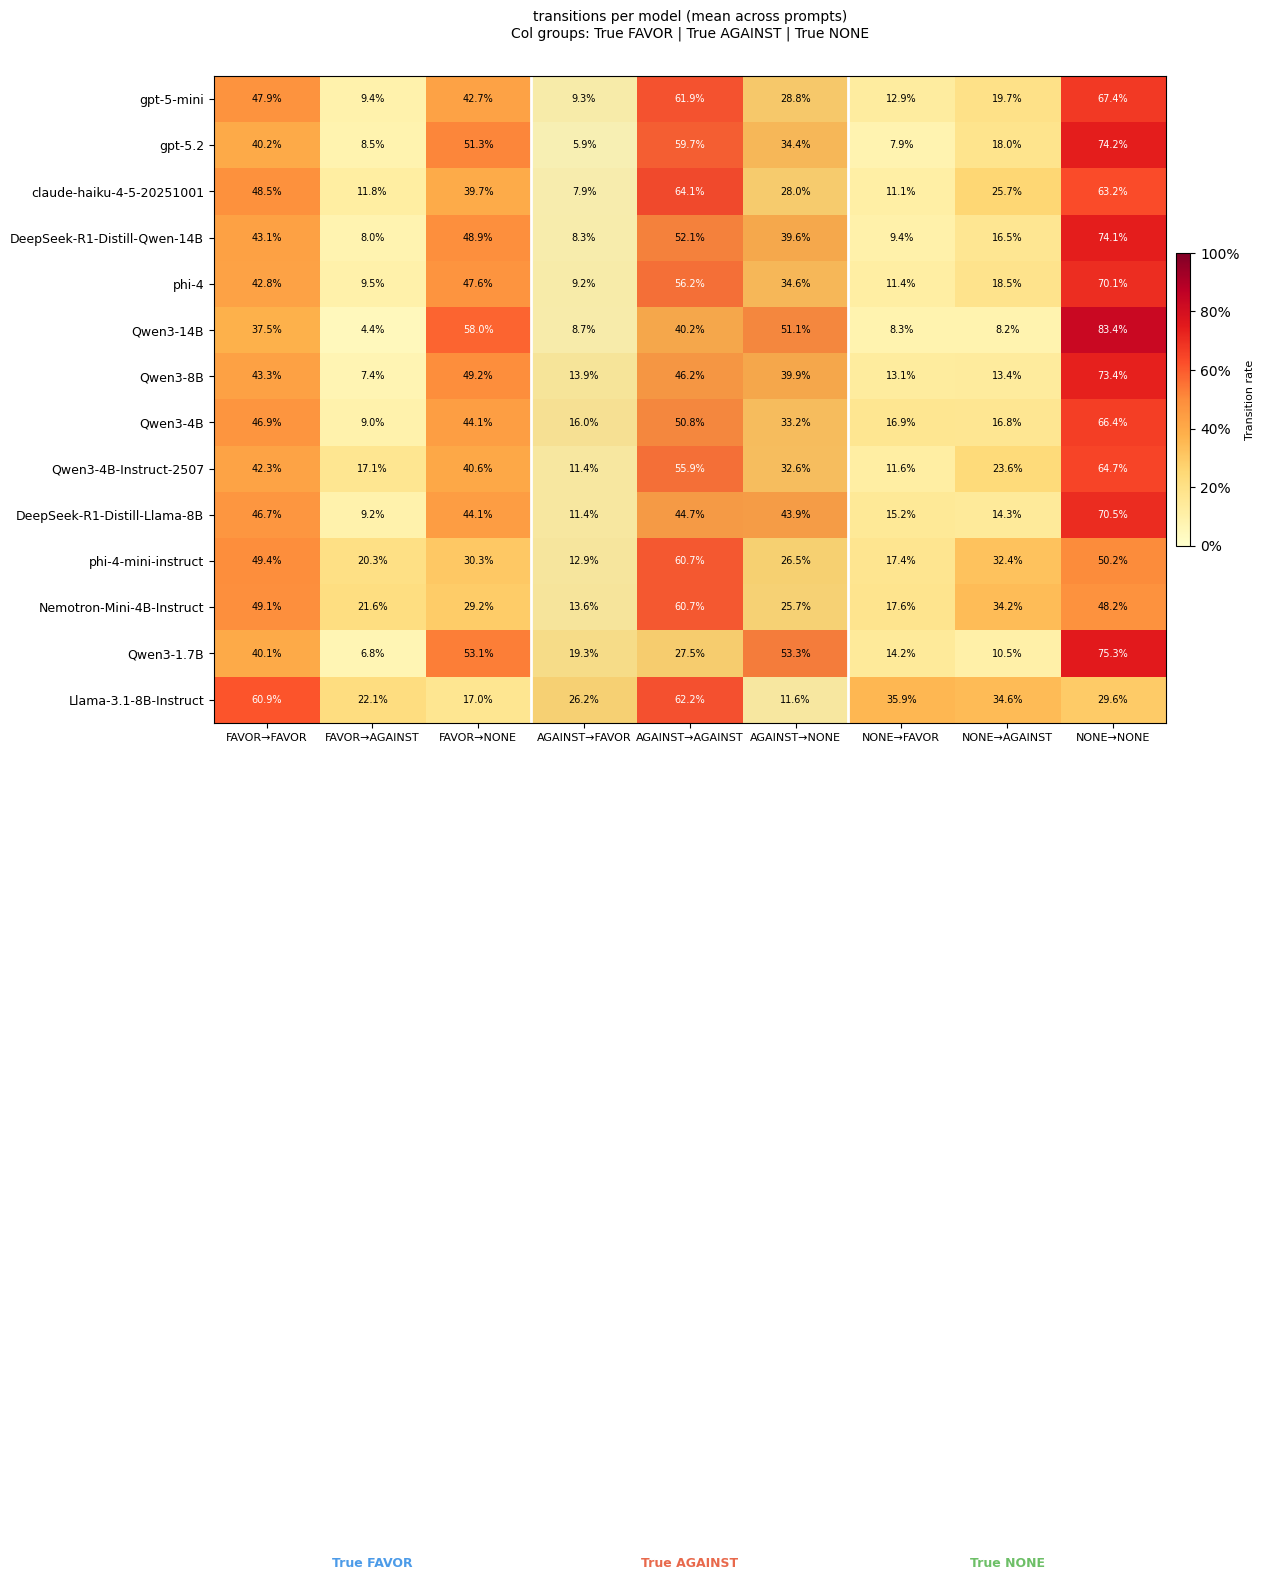

In [311]:
ALL_TRANS = [f"{tc}→{pc}" for tc in CLASSES for pc in CLASSES]
KEY_TRANS  = ["AGAINST→NONE","AGAINST→FAVOR","FAVOR→AGAINST","FAVOR→NONE","NONE→FAVOR","NONE→AGAINST"]

cm_rows_full = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX, ""); parts = stem.rsplit("_equal_", 1)
    if len(parts) != 2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    df = pd.read_csv(csv_path)
    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100: continue
    cm = confusion_matrix(df["original_stance"], df["predicted_stance"], labels=CLASSES).astype(float)
    cm_n = cm / cm.sum(axis=1, keepdims=True)
    row = {"model": model, "prompt": prompt}
    for ri, tc in enumerate(CLASSES):
        for ci, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_n[ri, ci]
    cm_rows_full.append(row)

cm_full_df = pd.DataFrame(cm_rows_full)
# Average per model across all prompts
cm_model = cm_full_df.groupby("model")[ALL_TRANS].mean()
cm_model = cm_model.reindex([m for m in model_order if m in cm_model.index])
hmap = cm_model.values
rlabels = list(cm_model.index)
n_t = len(CLASSES); n_tr = len(CLASSES)

fig, ax = plt.subplots(figsize=(n_t * n_tr * 1.4, max(5, len(rlabels) * 0.6)))
im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
cb = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cb.set_label("Transition rate", fontsize=8)
cb.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for g in range(1, n_t):
    ax.axvline(g * n_tr - 0.5, color="white", linewidth=2)
for di in range(n_t):
    if di % 2 == 1:
        ax.axvspan(di * n_tr - 0.5, (di + 1) * n_tr - 0.5, alpha=0.06, color="grey")

for r in range(hmap.shape[0]):
    for c in range(hmap.shape[1]):
        v = hmap[r, c]
        ax.text(c, r, f"{v*100:.1f}%", ha="center", va="center", fontsize=7,
                color="black" if v < 0.55 else "white")

ax.set_yticks(range(len(rlabels))); ax.set_yticklabels(rlabels, fontsize=9)
ax.set_xticks(range(len(ALL_TRANS)))
ax.set_xticklabels(ALL_TRANS, fontsize=8)

for gi, tc in enumerate(CLASSES):
    mid = gi * n_tr + (n_tr - 1) / 2
    ax.text(mid, -1.3, f"True {tc}", ha="center", va="center", fontsize=9,
            fontweight="bold", color=CLASS_COLORS[tc],
            transform=ax.get_xaxis_transform())

ax.set_title("transitions per model (mean across prompts)\nCol groups: True FAVOR | True AGAINST | True NONE",
             fontsize=10, pad=28)
plt.tight_layout()
plt.show()

In [312]:
# ── Tables for Confusion Transition Heatmap ──────────────────────────
print("=== Confusion transitions per model (mean across prompts) ===")
display(cm_model[ALL_TRANS].round(3))
print(cm_model[ALL_TRANS].round(3).to_csv())

print("\n=== Confusion transitions per model × prompt ===")
_cm_pp = cm_full_df.set_index(["model", "prompt"])[ALL_TRANS].round(3)
display(_cm_pp)
print(_cm_pp.to_csv())


=== Confusion transitions per model (mean across prompts) ===


,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
model,,,,,,,,,
gpt-5-mini,0.479,0.094,0.427,0.093,0.619,0.288,0.129,0.197,0.674
gpt-5.2,0.402,0.085,0.513,0.059,0.597,0.344,0.079,0.180,0.742
claude-haiku-4-5-20251001,0.485,0.118,0.397,0.079,0.641,0.280,0.111,0.257,0.632
DeepSeek-R1-Distill-Qwen-14B,0.431,0.080,0.489,0.083,0.521,0.396,0.094,0.165,0.741
phi-4,0.428,0.095,0.476,0.092,0.562,0.346,0.114,0.185,0.701
Qwen3-14B,0.375,0.044,0.580,0.087,0.402,0.511,0.083,0.082,0.834
Qwen3-8B,0.433,0.074,0.492,0.139,0.462,0.399,0.131,0.134,0.734
Qwen3-4B,0.469,0.090,0.441,0.160,0.508,0.332,0.169,0.168,0.664
Qwen3-4B-Instruct-2507,0.423,0.171,0.406,0.114,0.559,0.326,0.116,0.236,0.647


model,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
gpt-5-mini,0.479,0.094,0.427,0.093,0.619,0.288,0.129,0.197,0.674
gpt-5.2,0.402,0.085,0.513,0.059,0.597,0.344,0.079,0.18,0.742
claude-haiku-4-5-20251001,0.485,0.118,0.397,0.079,0.641,0.28,0.111,0.257,0.632
DeepSeek-R1-Distill-Qwen-14B,0.431,0.08,0.489,0.083,0.521,0.396,0.094,0.165,0.741
phi-4,0.428,0.095,0.476,0.092,0.562,0.346,0.114,0.185,0.701
Qwen3-14B,0.375,0.044,0.58,0.087,0.402,0.511,0.083,0.082,0.834
Qwen3-8B,0.433,0.074,0.492,0.139,0.462,0.399,0.131,0.134,0.734
Qwen3-4B,0.469,0.09,0.441,0.16,0.508,0.332,0.169,0.168,0.664
Qwen3-4B-Instruct-2507,0.423,0.171,0.406,0.114,0.559,0.326,0.116,0.236,0.647
DeepSeek-R1-Distill-Llama-8B,0.467,0.092,0.441,0.114,0.447,0.439,0.152,0.143,0.705
phi-4-mini-instruct,0.494,0.203,0.303,0.129,0.607,0.265,0.174,0.324,0.502
Nemotron-Mini-4B-Instruct,0.491,0.216,0.292,0.136,0.607,0.257,0.176,0.342,0.482
Qwen3-1.7B,0.401,0.068,0.531,0.1

FAVOR→FAVOR  \
model                        prompt                                      
DeepSeek-R1-Distill-Llama-8B cot                                 0.459   
                             default                             0.470   
                             default_no_label_definitions        0.543   
                             few_shot_12                         0.453   
                             few_shot_15                         0.421   
...                                                                ...   
phi-4                        few_shot_6                          0.429   
                             few_shot_9                          0.457   
                             question                            0.487   
                             task_definition                     0.401   
                             task_definition_scale               0.515   

                                                           FAVOR→AGAINST  \
model                        prompt                                        
DeepSeek-R1-Distill-Llama-8B cot                                   0.107   
                             default                               0.060   
                             default_no_label_definitions          0.142   
                             few_shot_12                           0.084   
                             few_shot_15                           0.082   
...                                                                  ...   
phi-4                        few_shot_6                            0.077   
                             few_shot_9                            0.086   
                             question                              0.187   
                             task_definition                       0.069   
                             task_definition_scale                 0.174   

                                                           FAVOR→NONE  \
model                        prompt                                     
DeepSeek-R1-Distill-Llama-8B cot                                0.433   
                             default                            0.470   
                             default_no_label_definitions       0.315   
                             few_shot_12                        0.464   
                             few_shot_15                        0.498   
...                                                               ...   
phi-4                        few_shot_6                         0.494   
                             few_shot_9                         0.457   
                             question                           0.326   
                             task_definition                    0.530   
                             task_definition_scale              0.311   

                                                           AGAINST→FAVOR  \
model                        prompt                                        
DeepSeek-R1-Distill-Llama-8B cot                                   0.090   
                             default                               0.137   
                             default_no_label_definitions          0.177   
                             few_shot_12                           0.090   
                             few_shot_15                           0.089   
...                                                                  ...   
phi-4                        few_shot_6                            0.093   
                             few_shot_9                            0.117   
                             question                              0.094   
                             task_definition                       0.084   
                             task_definition_scale                 0.130   

                                                           AGAINST→AGAINST  \
model                        prompt                                          
DeepSeek-R1-

model,prompt,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
DeepSeek-R1-Distill-Llama-8B,cot,0.459,0.107,0.433,0.09,0.51,0.4,0.128,0.188,0.684
DeepSeek-R1-Distill-Llama-8B,default,0.47,0.06,0.47,0.137,0.355,0.508,0.175,0.092,0.732
DeepSeek-R1-Distill-Llama-8B,default_no_label_definitions,0.543,0.142,0.315,0.177,0.508,0.315,0.243,0.196,0.561
DeepSeek-R1-Distill-Llama-8B,few_shot_12,0.453,0.084,0.464,0.09,0.438,0.472,0.121,0.137,0.742
DeepSeek-R1-Distill-Llama-8B,few_shot_15,0.421,0.082,0.498,0.089,0.434,0.477,0.13,0.117,0.754
DeepSeek-R1-Distill-Llama-8B,few_shot_3,0.399,0.069,0.532,0.086,0.396,0.519,0.103,0.102,0.795
DeepSeek-R1-Distill-Llama-8B,few_shot_6,0.442,0.069,0.489,0.086,0.43,0.484,0.128,0.116,0.756
DeepSeek-R1-Distill-Llama-8B,few_shot_9,0.442,0.086,0.472,0.095,0.444,0.461,0.129,0.124,0.748
DeepSeek-R1-Distill-Llama-8B,question,0.511,0.071,0.418,0.126,0.401,0.473,0.155,0.115,0.73
DeepSeek-R1-Distill-Llama-8B,t

## Step 13: Model Ranking Table — 3-class F1

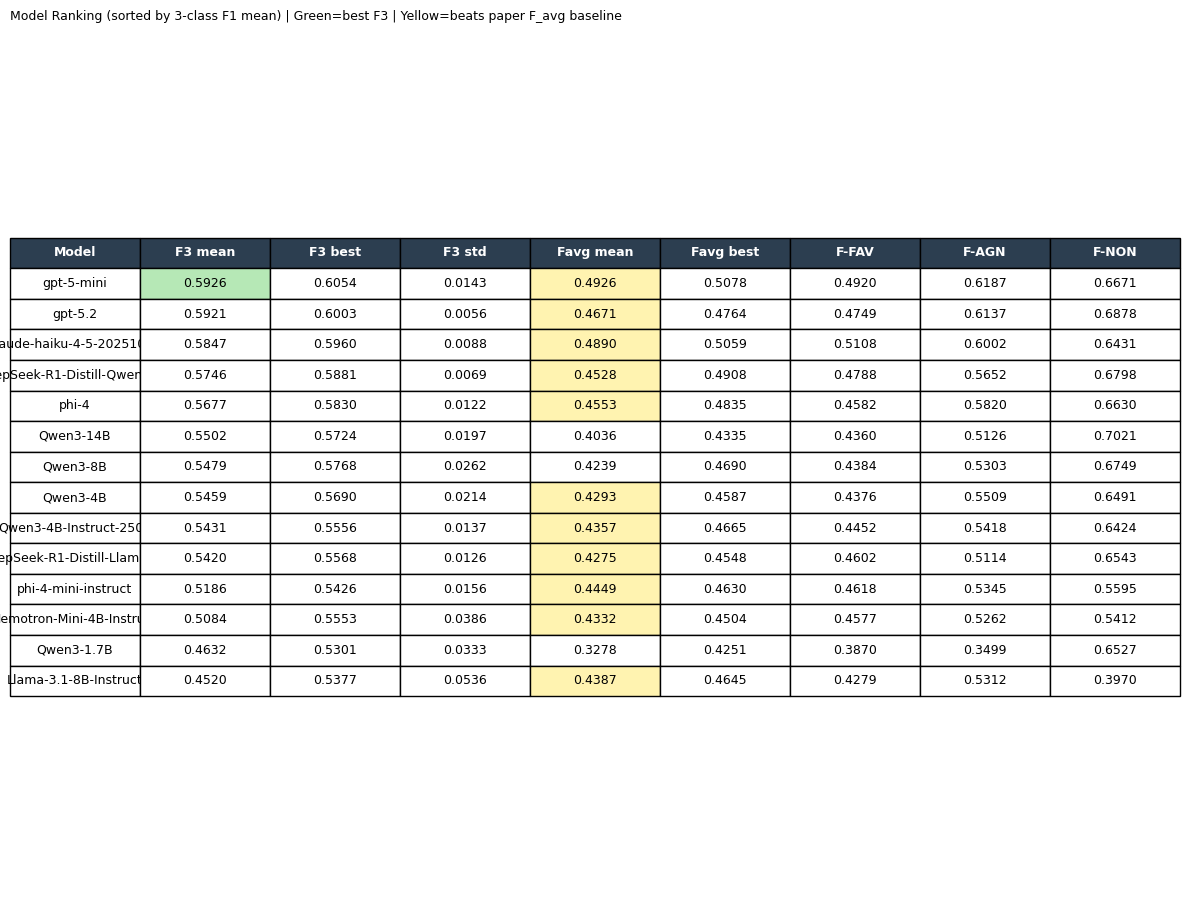

In [313]:
ranking = (
    llm_df.groupby("model")
    .agg(mean_f3=("3class_macro_f1","mean"), best_f3=("3class_macro_f1","max"),
         std_f3=("3class_macro_f1","std"),
         mean_f_avg=("f_avg","mean"), best_f_avg=("f_avg","max"),
         f_favor=("f_favor","mean"), f_against=("f_against","mean"), f_none=("f_none","mean"))
    .reset_index().sort_values("mean_f3", ascending=False).reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, max(3, len(ranking)*0.55 + 1.5)))
ax.axis("off")
cols = ["Model","F3 mean","F3 best","F3 std","Favg mean","Favg best","F-FAV","F-AGN","F-NON"]
data = [[r["model"], f"{r['mean_f3']:.4f}", f"{r['best_f3']:.4f}", f"{r['std_f3']:.4f}",
         f"{r['mean_f_avg']:.4f}", f"{r['best_f_avg']:.4f}",
         f"{r['f_favor']:.4f}", f"{r['f_against']:.4f}", f"{r['f_none']:.4f}"]
        for _,r in ranking.iterrows()]

BEST_F3   = ranking["mean_f3"].max()
REF_FAVG  = PAPER_FAVG["TTS (best indiv.)"]
cell_colors = []
for _,r in ranking.iterrows():
    is_best = abs(r["mean_f3"]-BEST_F3) < 1e-6
    beats   = r["mean_f_avg"] >= REF_FAVG
    c_f3  = "#b6e8b6" if is_best else "#ffffff"
    c_fav = "#fff3b0" if beats  else "#ffffff"
    cell_colors.append(["#ffffff", c_f3, "#ffffff", "#ffffff", c_fav, "#ffffff",
                        "#ffffff","#ffffff","#ffffff"])

tbl = ax.table(cellText=data, colLabels=cols, cellLoc="center", loc="center",
               cellColours=cell_colors)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.5)
for j in range(len(cols)):
    tbl[0,j].set_facecolor("#2c3e50")
    tbl[0,j].set_text_props(color="white", fontweight="bold")
ax.set_title("Model Ranking (sorted by 3-class F1 mean) | Green=best F3 | Yellow=beats paper F_avg baseline",
             fontsize=9, pad=10, loc="left")
plt.tight_layout(); plt.show()

## Step 14: Prompt Sensitivity — 3-class F1

                       model  mean_f3   std_f3  range_f3     best    worst
                  gpt-5-mini 0.592583 0.014264  0.048942       9R      CoT
                     gpt-5.2 0.592146 0.005556  0.017150       6R Question
   claude-haiku-4-5-20251001 0.584708 0.008806  0.029225       9R Question
DeepSeek-R1-Distill-Qwen-14B 0.574613 0.006871  0.023141       9R  Default
                       phi-4 0.567737 0.012208  0.033979      12R    Scale
                   Qwen3-14B 0.550244 0.019747  0.056784      12R  Default
                    Qwen3-8B 0.547903 0.026207  0.077145      15R   No-def
                    Qwen3-4B 0.545865 0.021447  0.071318       3R   No-def
      Qwen3-4B-Instruct-2507 0.543143 0.013669  0.042020 Task-def    Scale
DeepSeek-R1-Distill-Llama-8B 0.541956 0.012571  0.037192      CoT  Default
         phi-4-mini-instruct 0.518607 0.015592  0.047298 Task-def      CoT
   Nemotron-Mini-4B-Instruct 0.508364 0.038559  0.130135      15R    Scale
                  Qwen3-1

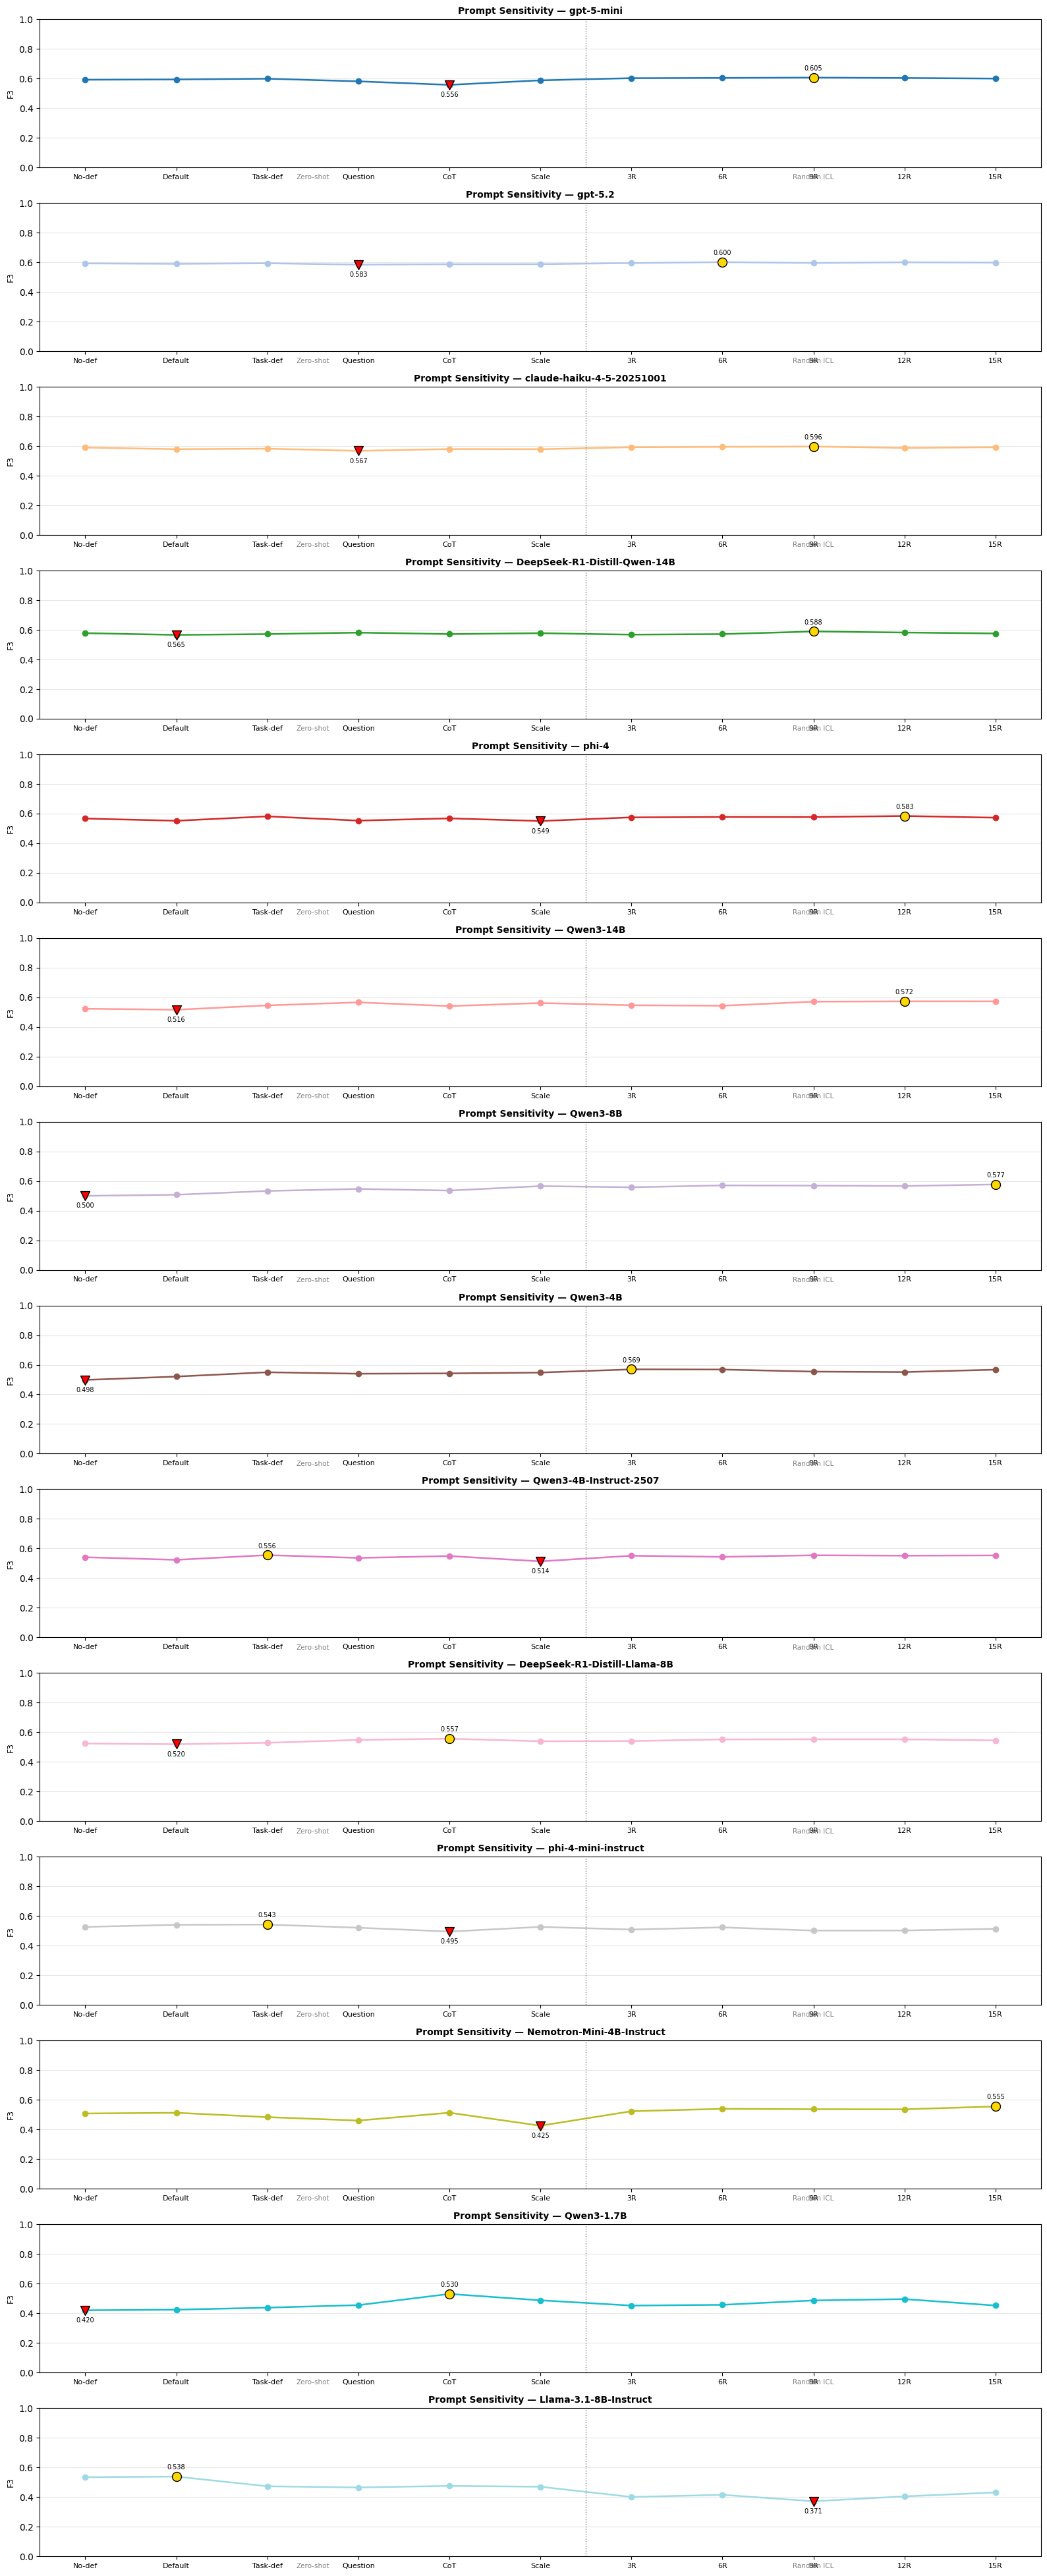

In [314]:
sens_rows = []
for model, grp in llm_df.groupby("model"):
    bi = grp["3class_macro_f1"].idxmax(); wi = grp["3class_macro_f1"].idxmin()
    sens_rows.append({"model":model, "mean_f3":grp["3class_macro_f1"].mean(),
                      "std_f3":grp["3class_macro_f1"].std(),
                      "range_f3":grp["3class_macro_f1"].max()-grp["3class_macro_f1"].min(),
                      "best":PROMPT_LABELS.get(grp.loc[bi,"prompt"],grp.loc[bi,"prompt"]),
                      "worst":PROMPT_LABELS.get(grp.loc[wi,"prompt"],grp.loc[wi,"prompt"])})
print(pd.DataFrame(sens_rows).sort_values("mean_f3",ascending=False).to_string(index=False))

n_m = len(model_order)
fig, axes = plt.subplots(n_m, 1, figsize=(max(16,len(available_prompts)*1.1), n_m*2.8), sharey=True)
if n_m==1: axes=[axes]
for ai, model in enumerate(model_order):
    ax  = axes[ai]
    mdf = llm_df[llm_df["model"]==model].set_index("prompt")
    y   = [mdf.loc[p,"3class_macro_f1"] if p in mdf.index else float("nan") for p in available_prompts]
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=6, color=cmap(ai), label=model)
    valid = [(xi,yi) for xi,yi in zip(x_pos,y) if not np.isnan(yi)]
    if valid:
        bx,by = max(valid,key=lambda t:t[1]); wx,wy = min(valid,key=lambda t:t[1])
        ax.scatter([bx],[by],s=100,color="gold",edgecolors="black",zorder=5)
        ax.scatter([wx],[wy],s=100,color="red",edgecolors="black",marker="v",zorder=5)
        ax.annotate(f"{by:.3f}",(bx,by),textcoords="offset points",xytext=(0,8),ha="center",fontsize=7)
        ax.annotate(f"{wy:.3f}",(wx,wy),textcoords="offset points",xytext=(0,-13),ha="center",fontsize=7)
    add_icl_sep(ax)
    ax.set_ylim(0,1); ax.set_xticks(x_pos); ax.set_xticklabels(x_labels,fontsize=8)
    ax.set_ylabel("F3",fontsize=9)
    ax.set_title(f"Prompt Sensitivity — {model}",fontsize=10,fontweight="bold")
    ax.grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

## Step 15: F3 by Prompt Family

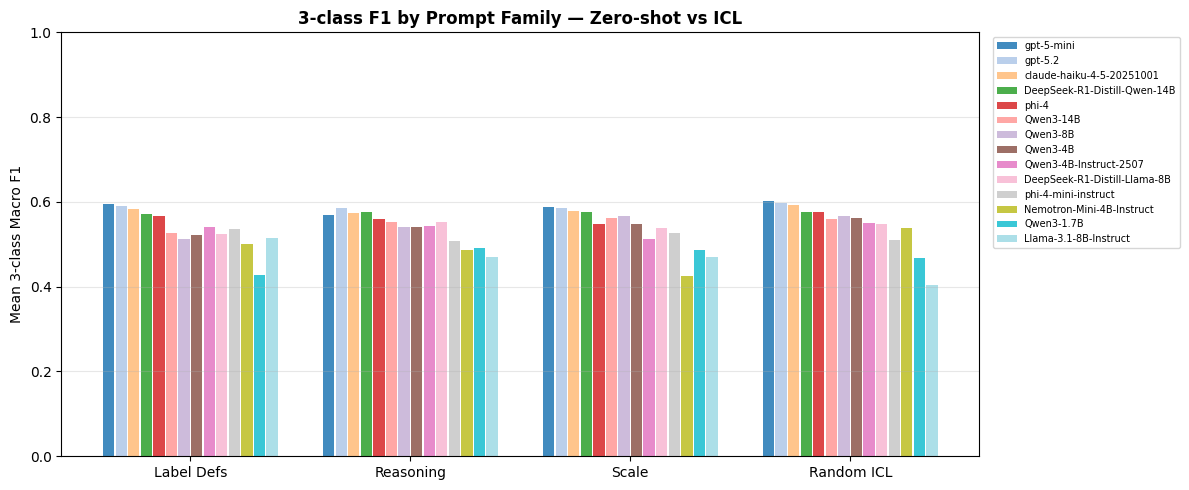

In [315]:
FAMILIES = OrderedDict([
    ("Label Defs",  {"prompts":["default_no_label_definitions","default","task_definition"], "color":"#E8694C"}),
    ("Reasoning",   {"prompts":["cot","question"],                                          "color":"#984ea3"}),
    ("Scale",       {"prompts":["task_definition_scale"],                                   "color":"#999999"}),
    ("Random ICL",  {"prompts":["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"], "color":"#4C9BE8"}),
])
family_names = list(FAMILIES.keys())
n_fam = len(family_names); x_fam = np.arange(n_fam)
n_mf  = len(model_order);  bw = 0.8/max(n_mf,1)

fig, ax = plt.subplots(figsize=(max(12,n_fam*3), 5))
for mi, model in enumerate(model_order):
    mdf = llm_df[llm_df["model"]==model]
    means_fam = [mdf[mdf["prompt"].isin([p for p in fam["prompts"] if p in mdf["prompt"].values])]["3class_macro_f1"].mean()
                 if any(p in mdf["prompt"].values for p in fam["prompts"]) else float("nan")
                 for fam in FAMILIES.values()]
    ax.bar(x_fam + (mi-(n_mf-1)/2)*bw, means_fam, width=bw*0.9, color=cmap(mi), label=model, alpha=0.85)
ax.set_xticks(x_fam); ax.set_xticklabels(family_names, fontsize=10)
ax.set_ylim(0,1); ax.set_ylabel("Mean 3-class Macro F1", fontsize=10)
ax.set_title("3-class F1 by Prompt Family — Zero-shot vs ICL", fontsize=12, fontweight="bold")
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 16: Per-target Analysis — Label Distribution + Per-class F1

4-row × 5-column grid:  
- **Row 0**: Gold label distribution per target  
- **Rows 1–3**: FAVOR / AGAINST / NONE F1 per model (best prompt), per target

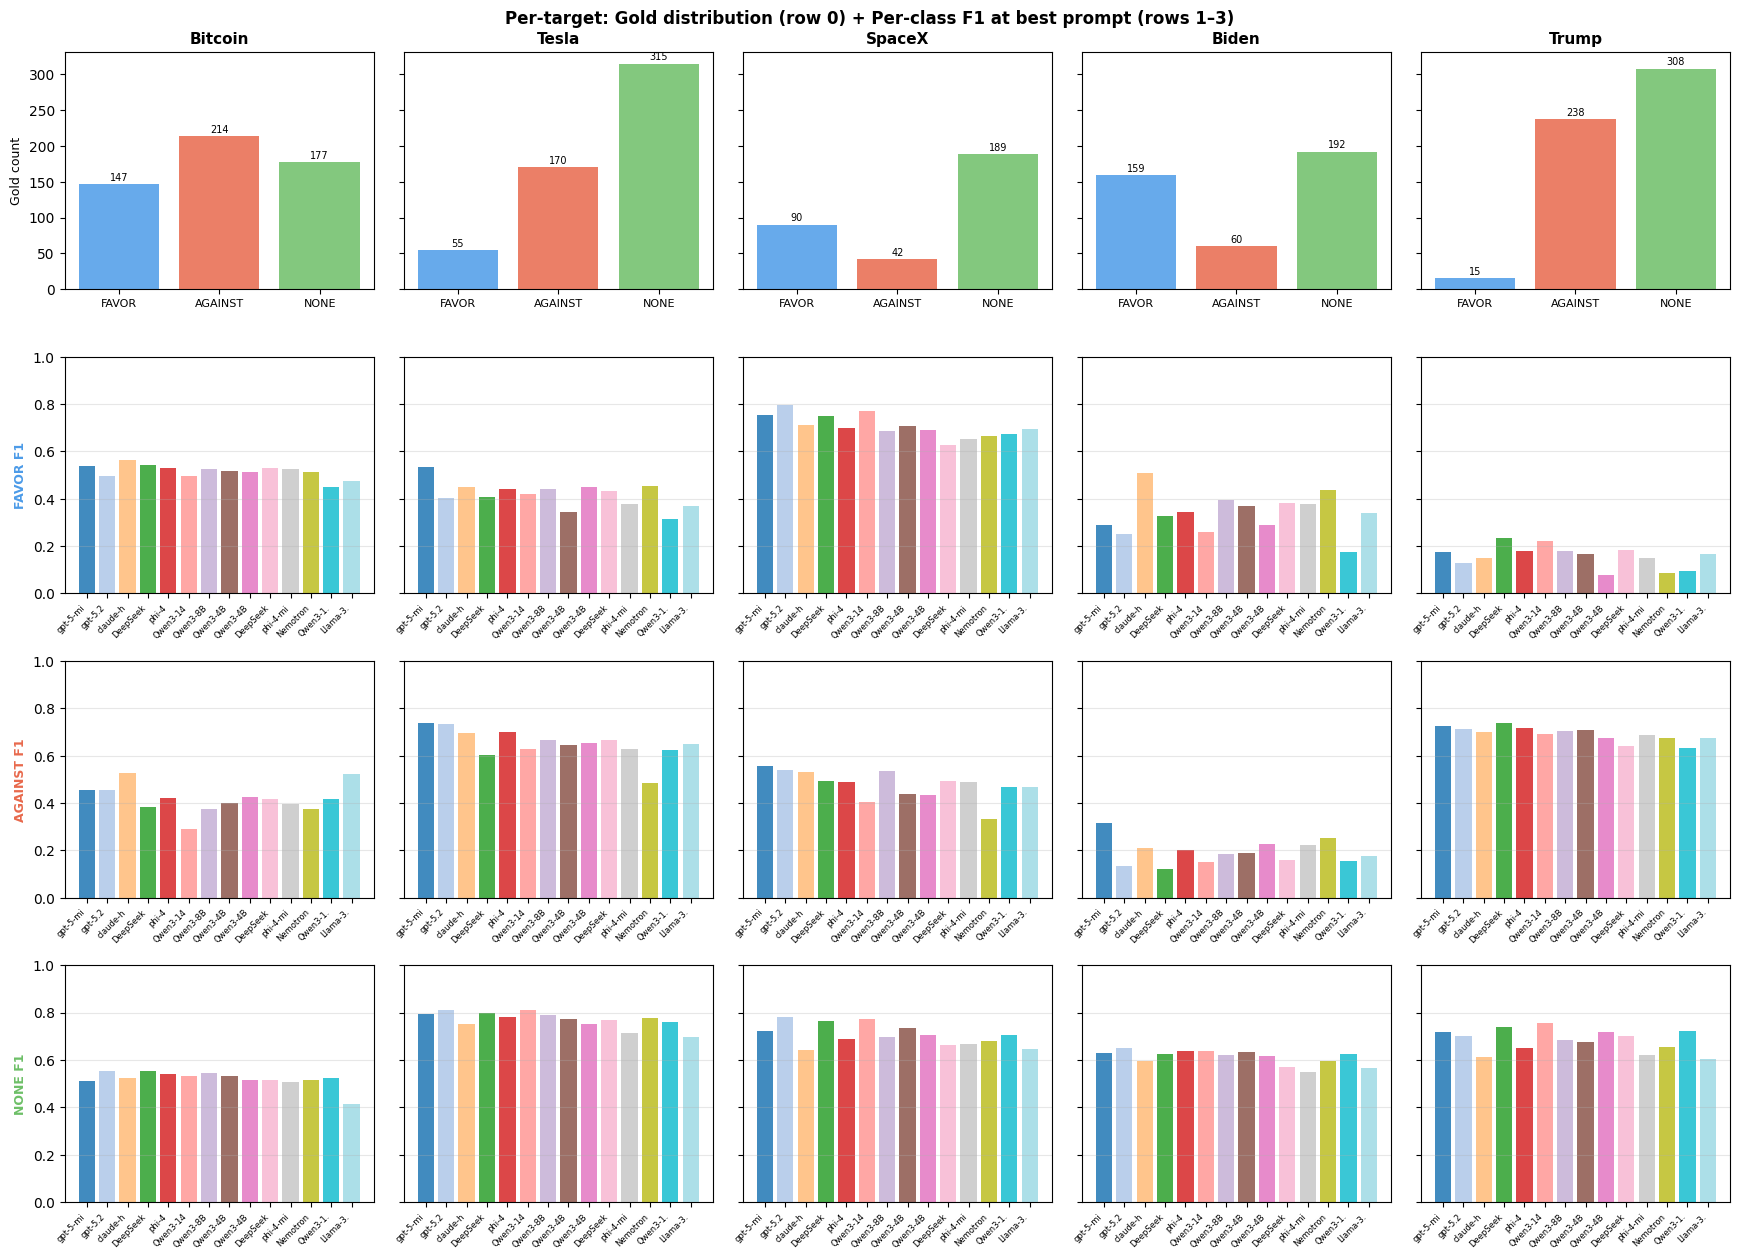

In [316]:
gold_df = pd.read_csv(GOLD_PATH)
gold_df["gold"] = gold_df["stance_label"].astype(str).str.upper().str.strip()
gold_df["id"]   = gold_df["id"].astype(str)

# Load per-target predictions for all experiments
tgt_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model, prompt = parts
    if prompt not in PROMPT_ORDER: continue
    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    preds["id"]   = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_df[["id","gold","query"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]
    for target in TARGET_ORDER:
        sub = merged[merged["query"]==target]
        if len(sub)==0: continue
        _,_,f,_ = precision_recall_fscore_support(sub["gold"],sub["pred"],labels=CLASSES,average=None,zero_division=0)
        tgt_rows.append({"model":model,"prompt":prompt,"target":target,
                         "f3":f.mean(),"f_favor":f[0],"f_against":f[1],"f_none":f[2],"n":len(sub)})

tgt_df = pd.DataFrame(tgt_rows)

# Best prompt per model (by overall F3)
best_prompt = {m: llm_df[llm_df["model"]==m].sort_values("3class_macro_f1").iloc[-1]["prompt"]
               for m in model_order}

# ── Plot ─────────────────────────────────────────────────────────────────────
n_rows_plot = 4; n_cols_plot = len(TARGET_ORDER)
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(n_cols_plot*3.5, n_rows_plot*3.2), sharey="row")

for ci, target in enumerate(TARGET_ORDER):
    # Row 0: gold label distribution
    ax = axes[0,ci]
    sub_gold = gold_df[gold_df["query"]==target]
    counts   = sub_gold["gold"].value_counts().reindex(CLASSES, fill_value=0)
    ax.bar(CLASSES, counts.values, color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.85)
    for xi,v in enumerate(counts.values):
        ax.text(xi, v+5, str(v), ha="center", fontsize=7)
    ax.set_title(target, fontsize=11, fontweight="bold")
    if ci==0: ax.set_ylabel("Gold count", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

    # Rows 1–3: per-class F1 at best prompt per model
    for ri, cls in enumerate(CLASSES):
        ax = axes[ri+1, ci]
        f_col = f"f_{cls.lower()}"
        x_m = np.arange(len(model_order))
        for mi, model in enumerate(model_order):
            bp  = best_prompt[model]
            sub = tgt_df[(tgt_df["model"]==model)&(tgt_df["prompt"]==bp)&(tgt_df["target"]==target)]
            val = sub[f_col].values[0] if len(sub)>0 else float("nan")
            ax.bar(x_m[mi], val, color=cmap(mi), alpha=0.85)
        ax.set_xticks(x_m)
        ax.set_xticklabels([m[:8] for m in model_order], rotation=45, ha="right", fontsize=6)
        ax.set_ylim(0,1)
        if ci==0:
            ax.set_ylabel(f"{cls} F1", fontsize=9, color=CLASS_COLORS[cls], fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-target: Gold distribution (row 0) + Per-class F1 at best prompt (rows 1–3)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 17: Per-target Overall F3 — Table + Chart

Target       F3 mean   F3 std   F-FAV   F-AGN   F-NON
─────────────────────────────────────────────────────
Bitcoin       0.4717   0.0385  0.5000  0.4115  0.5035
Tesla         0.5815   0.0672  0.3887  0.6236  0.7322
SpaceX        0.5935   0.0631  0.6752  0.4442  0.6610
Biden         0.3635   0.0314  0.3275  0.1834  0.5795
Trump         0.4867   0.0664  0.1565  0.6617  0.6421


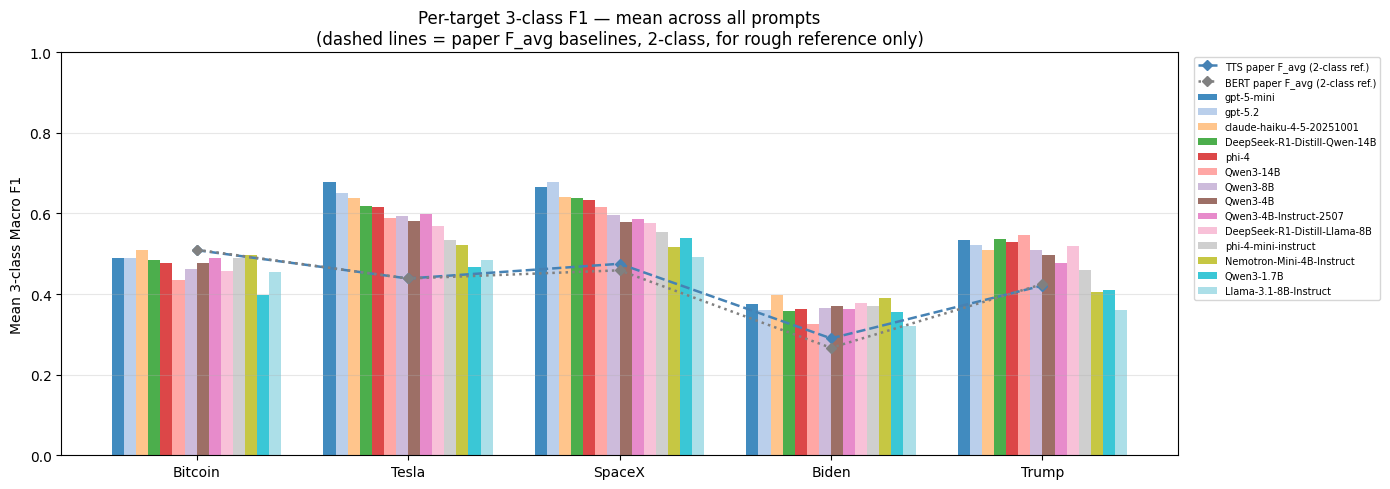

In [317]:
tgt_mean = tgt_df.groupby(["model","target"])[["f3","f_favor","f_against","f_none"]].mean().reset_index()

# Table
tbl_t = tgt_df.groupby("target").agg(mean_f3=("f3","mean"),std_f3=("f3","std"),
            mean_ffav=("f_favor","mean"),mean_fagn=("f_against","mean"),mean_fnon=("f_none","mean"))\
              .reindex(TARGET_ORDER).reset_index()
hdr = f"{'Target':<10} {'F3 mean':>9} {'F3 std':>8} {'F-FAV':>7} {'F-AGN':>7} {'F-NON':>7}"
print(hdr); print("─"*len(hdr))
for _,r in tbl_t.iterrows():
    print(f"{r['target']:<10} {r['mean_f3']:>9.4f} {r['std_f3']:>8.4f} "
          f"{r['mean_ffav']:>7.4f} {r['mean_fagn']:>7.4f} {r['mean_fnon']:>7.4f}")

# Chart
x_t = np.arange(len(TARGET_ORDER))
width = 0.8/max(len(model_order),1)
offsets = np.linspace(-(0.8-width)/2,(0.8-width)/2,len(model_order))

fig, ax = plt.subplots(figsize=(14,5))
for mi,model in enumerate(model_order):
    mdf = tgt_mean[tgt_mean["model"]==model].set_index("target")
    y   = [mdf.loc[t,"f3"] if t in mdf.index else np.nan for t in TARGET_ORDER]
    ax.bar(x_t+offsets[mi], y, width=width, label=model, color=cmap(mi), alpha=0.85)

# Paper per-target F_avg as reference lines (labelled as 2-class)
for bl_name, bl_col, bl_ls in [("TTS","steelblue","--"),("BERT","grey",":")]:
    bl_vals = [PAPER_PER_TARGET[bl_name].get(t,np.nan) for t in TARGET_ORDER]
    ax.plot(x_t, bl_vals, color=bl_col, linestyle=bl_ls, linewidth=1.8,
            marker="D", markersize=5, label=f"{bl_name} paper F_avg (2-class ref.)")

ax.set_xticks(x_t); ax.set_xticklabels(TARGET_ORDER, fontsize=10)
ax.set_ylim(0,1); ax.set_ylabel("Mean 3-class Macro F1")
ax.set_title("Per-target 3-class F1 — mean across all prompts\n"
             "(dashed lines = paper F_avg baselines, 2-class, for rough reference only)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01,1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Step 18: Per-target Confusion Transition Heatmap

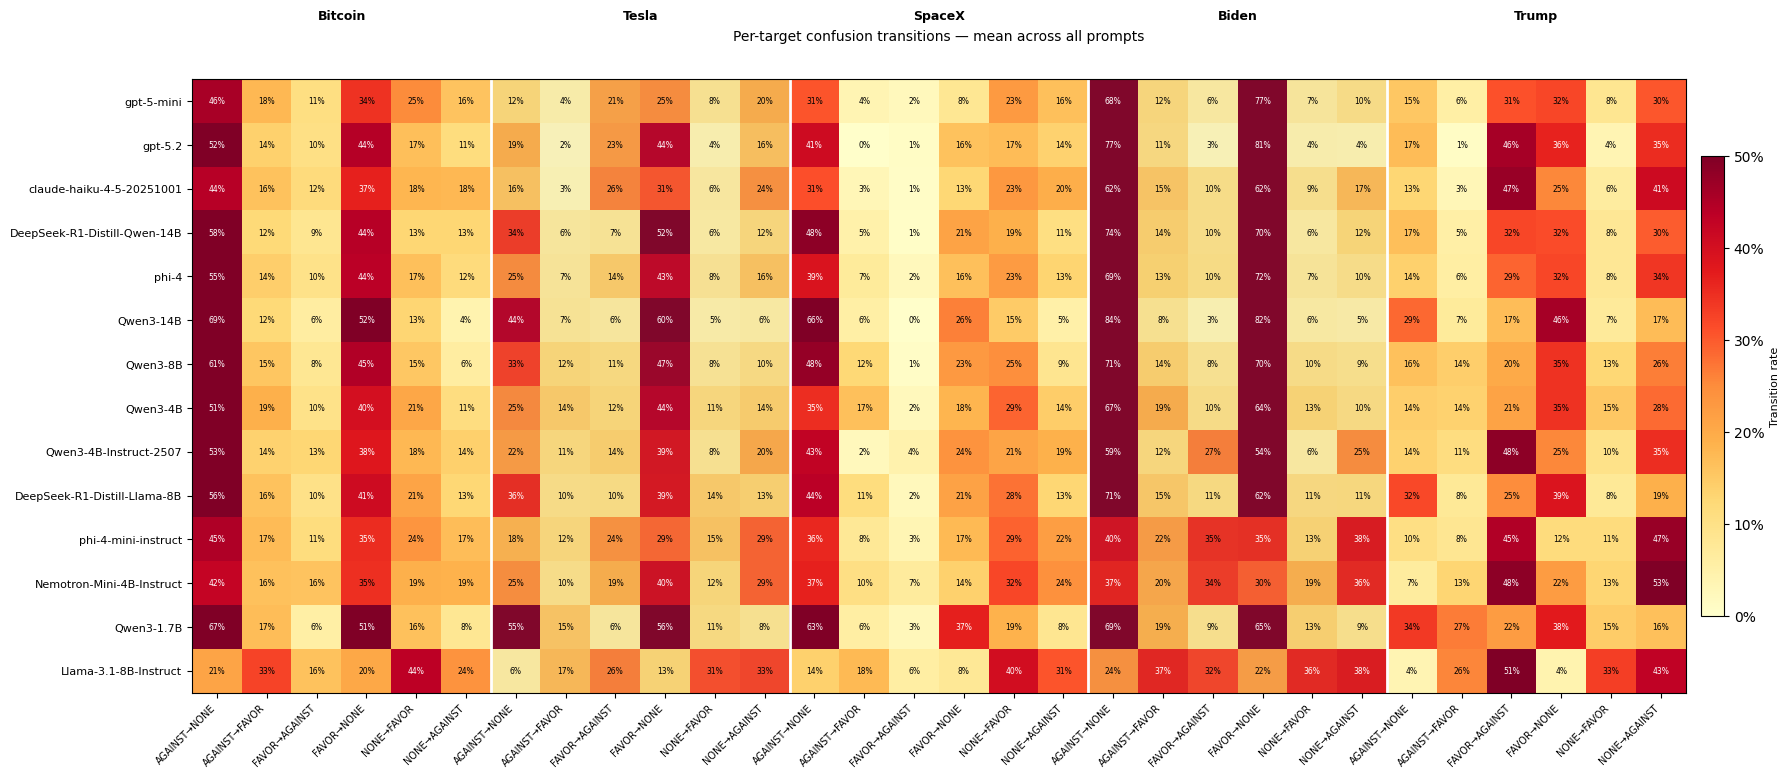

In [318]:
ct_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_2371"): continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists(): continue
    stem = folder.replace(PREFIX,""); parts = stem.rsplit("_equal_",1)
    if len(parts)!=2: continue
    model,prompt = parts
    if prompt not in PROMPT_ORDER: continue
    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(lambda x: canon(x) if pd.notna(x) else None)
    preds["id"]   = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_df[["id","gold","query"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]
    for target in TARGET_ORDER:
        sub = merged[merged["query"]==target]
        if len(sub)<5: continue
        cm = confusion_matrix(sub["gold"],sub["pred"],labels=CLASSES)
        cm_p = cm/cm.sum(axis=1,keepdims=True).clip(min=1)
        entry = {"model":model,"prompt":prompt,"target":target}
        for tc,pc in [("AGAINST","NONE"),("AGAINST","FAVOR"),("FAVOR","AGAINST"),
                      ("FAVOR","NONE"),("NONE","FAVOR"),("NONE","AGAINST")]:
            entry[f"{tc}→{pc}"] = cm_p[CLASSES.index(tc),CLASSES.index(pc)]
        ct_rows.append(entry)

ct_df  = pd.DataFrame(ct_rows)
ct_mean= ct_df.groupby(["model","target"])[KEY_TRANS].mean().reset_index()

n_t=len(TARGET_ORDER); n_tr=len(KEY_TRANS); n_cols=n_t*n_tr; n_m_ct=len(model_order)
mat = np.full((n_m_ct,n_cols), np.nan)
for ri,model in enumerate(model_order):
    for di,target in enumerate(TARGET_ORDER):
        sub = ct_mean[(ct_mean["model"]==model)&(ct_mean["target"]==target)]
        if sub.empty: continue
        for ti,trans in enumerate(KEY_TRANS):
            mat[ri, di*n_tr+ti] = sub.iloc[0][trans]

fig,ax = plt.subplots(figsize=(max(18,n_cols*0.6), max(4,n_m_ct*0.42+2)))
im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=0.5)
ax.set_xticks(range(n_cols)); ax.set_xticklabels(KEY_TRANS*n_t, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_m_ct)); ax.set_yticklabels(model_order, fontsize=8)
for di,target in enumerate(TARGET_ORDER):
    ax.text(di*n_tr+(n_tr-1)/2, -1.8, target, ha="center", va="bottom", fontsize=9, fontweight="bold")
    if di>0: ax.axvline(di*n_tr-0.5, color="white", linewidth=2)
for r in range(n_m_ct):
    for c in range(n_cols):
        v=mat[r,c]
        if not np.isnan(v):
            ax.text(c,r,f"{v:.0%}",ha="center",va="center",fontsize=5.5,
                    color="black" if v<0.35 else "white")
for di in range(n_t):
    if di%2==1: ax.axvspan(di*n_tr-0.5,(di+1)*n_tr-0.5,alpha=0.06,color="grey")
cb = fig.colorbar(im,ax=ax,fraction=0.015,pad=0.01)
cb.set_label("Transition rate",fontsize=8)
cb.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Per-target confusion transitions — mean across all prompts", fontsize=10, pad=28)
plt.tight_layout(); plt.show()

In [319]:
# ── Table for Per-target Confusion Heatmap ───────────────────────────
print("=== Per-target confusion transitions (mean across prompts) ===")
display(ct_mean.round(3))
print(ct_mean.round(3).to_csv(index=False))


=== Per-target confusion transitions (mean across prompts) ===


,model,target,AGAINST→NONE,AGAINST→FAVOR,FAVOR→AGAINST,FAVOR→NONE,NONE→FAVOR,NONE→AGAINST
0,DeepSeek-R1-Distill-Llama-8B,Biden,0.711,0.147,0.107,0.623,0.111,0.113
1,DeepSeek-R1-Distill-Llama-8B,Bitcoin,0.563,0.161,0.098,0.409,0.211,0.127
2,DeepSeek-R1-Distill-Llama-8B,SpaceX,0.439,0.113,0.023,0.213,0.276,0.128
3,DeepSeek-R1-Distill-Llama-8B,Tesla,0.355,0.098,0.102,0.390,0.144,0.134
4,DeepSeek-R1-Distill-Llama-8B,Trump,0.319,0.076,0.248,0.388,0.076,0.190
...,...,...,...,...,...,...,...,...
65,phi-4-mini-instruct,Biden,0.398,0.221,0.348,0.353,0.129,0.384
66,phi-4-mini-instruct,Bitcoin,0.451,0.173,0.113,0.353,0.235,0.169
67,phi-4-mini-instruct,SpaceX,0.359,0.078,0.033,0.175,0.292,0.219
68,phi-4-mini-instruct,Tesla,0.184,0.117,0.240,0.288,0.155,0.292


model,target,AGAINST→NONE,AGAINST→FAVOR,FAVOR→AGAINST,FAVOR→NONE,NONE→FAVOR,NONE→AGAINST
DeepSeek-R1-Distill-Llama-8B,Biden,0.711,0.147,0.107,0.623,0.111,0.113
DeepSeek-R1-Distill-Llama-8B,Bitcoin,0.563,0.161,0.098,0.409,0.211,0.127
DeepSeek-R1-Distill-Llama-8B,SpaceX,0.439,0.113,0.023,0.213,0.276,0.128
DeepSeek-R1-Distill-Llama-8B,Tesla,0.355,0.098,0.102,0.39,0.144,0.134
DeepSeek-R1-Distill-Llama-8B,Trump,0.319,0.076,0.248,0.388,0.076,0.19
DeepSeek-R1-Distill-Qwen-14B,Biden,0.738,0.138,0.096,0.696,0.057,0.122
DeepSeek-R1-Distill-Qwen-14B,Bitcoin,0.584,0.122,0.085,0.442,0.127,0.127
DeepSeek-R1-Distill-Qwen-14B,SpaceX,0.485,0.048,0.006,0.212,0.19,0.107
DeepSeek-R1-Distill-Qwen-14B,Tesla,0.337,0.065,0.074,0.517,0.056,0.116
DeepSeek-R1-Distill-Qwen-14B,Trump,0.167,0.053,0.321,0.315,0.079,0.298
Llama-3.1-8B-Instruct,Biden,0.242,0.365,0.325,0.219,0.36,0.38
Llama-3.1-8B-Instruct,Bitcoin,0.211,0.325,0.161,0.203,0.436,0.239
Llama-3.1-8B-Instruct,SpaceX,0.137,0.175,0.059,0.077,0.403,0.306
Llama

## § Marginal Shift Analysis

Marginal shift per class = **predicted share − gold share** (percentage points), averaged equally across all prompt settings.

**Stratified bootstrap (1 000 iters):** documents are resampled *within each target/domain* independently, preserving per-stratum sample sizes and isolating within-topic variance. Whiskers show 2.5/97.5 percentiles.

[Shift] 14 models · 11 prompts · 2371 docs


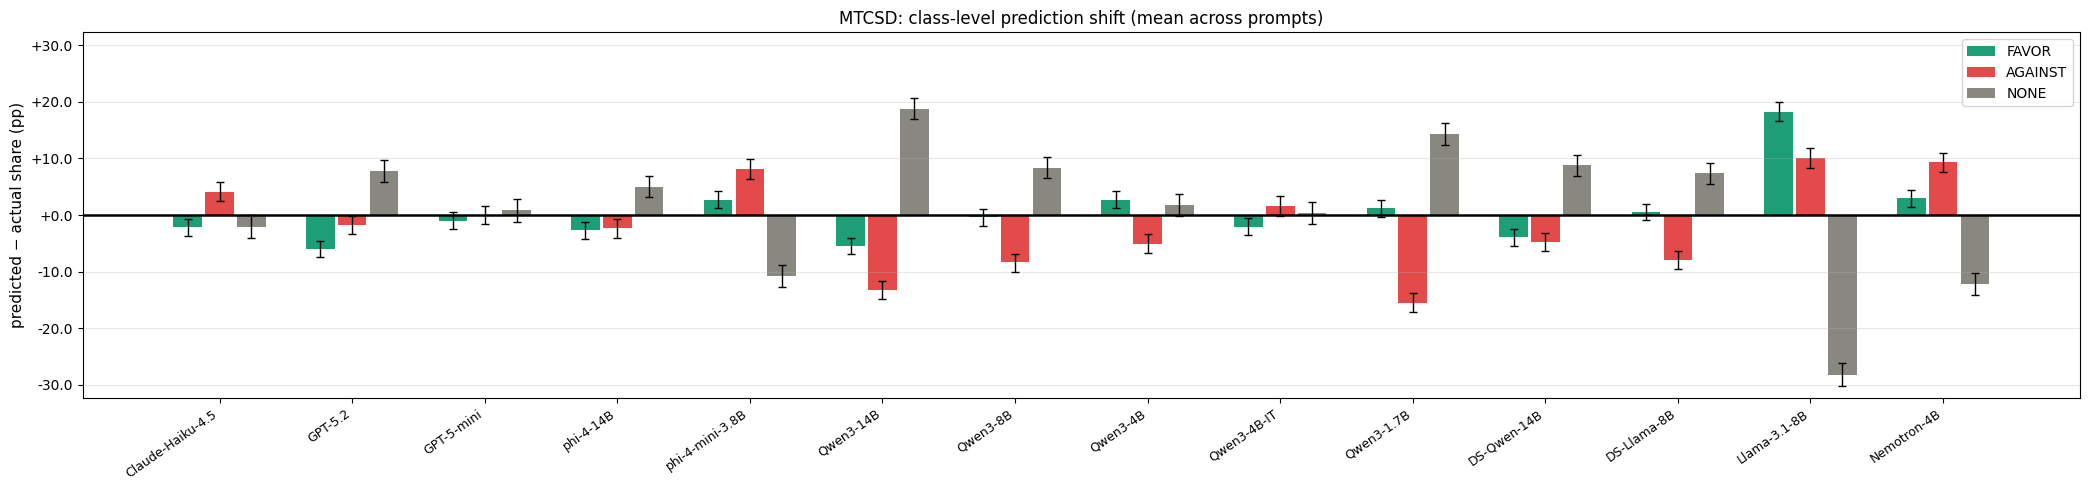

Saved → ../data_out/stance/stance_analysis/marginal_shift_mtcsd.png

=== Table 1: Per-model Marginal Shifts (pp) — MTCSD ===
Model                                        F1  ΔFAVOR [95% CI]  ΔAGAINST [95% CI]  ΔNONE [95% CI]
────────────────────────────────────────────────────────────────────────────────────────────────────────────
claude-haiku-4-5-20251001                0.5847   -2.2 [ -3.6, -0.7]   +4.1 [ +2.4, +5.8]   -2.1 [ -4.0, +0.0]
gpt-5.2                                  0.5921   -6.0 [ -7.5, -4.6]   -1.7 [ -3.4, -0.1]   +7.7 [ +5.8, +9.7]
gpt-5-mini                               0.5926   -1.0 [ -2.5, +0.5]   +0.0 [ -1.7, +1.6]   +0.9 [ -1.1, +2.8]
phi-4                                    0.5677   -2.7 [ -4.2, -1.2]   -2.3 [ -4.0, -0.8]   +5.0 [ +3.1, +7.0]
phi-4-mini-instruct                      0.5186   +2.6 [ +1.2, +4.2]   +8.1 [ +6.4, +9.8]  -10.8 [-12.7, -8.7]
Qwen3-14B                                0.5502   -5.5 [ -6.8, -4.1]  -13.3 [-14.9,-11.6]  +18.8 [+16.9,+20.6]


In [320]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
from sklearn.metrics import f1_score as _f1_score

# ── config ────────────────────────────────────────────────────────────────────
_DATASET   = "MTCSD"
_STRAT_COL = "query"
_N_BOOT    = 1000
_SEED      = 42
_CLR       = {"FAVOR": "#1D9E75", "AGAINST": "#E24B4A", "NONE": "#888780"}
_OUT       = Path("../data_out/stance/stance_analysis")
_OUT.mkdir(parents=True, exist_ok=True)



_canon = lambda s: s   # canonicalise stance labels → FAVOR / AGAINST / NONE

# ── load all predictions ──────────────────────────────────────────────────────
_rows = []
for _fld in sorted(os.listdir(RESULTS_DIR)):
    if not _fld.startswith(PREFIX.rstrip("_")):
        continue
    _csv = RESULTS_DIR / _fld / "document_assignments.csv"
    if not _csv.exists():
        continue
    _stem = _fld[len(PREFIX):]
    _pts  = _stem.rsplit("_equal_", 1)
    if len(_pts) != 2:
        continue
    _m, _p = _pts
    if _p not in PROMPT_ORDER:
        continue
    _df = pd.read_csv(_csv)
    _df["model"]  = _m
    _df["prompt"] = _p
    _df["gold"]   = _df["original_stance"].apply(
        lambda x: _canon(str(x).upper().strip()) if pd.notna(x) else "")
    _df["pred"]   = _df["predicted_stance"].apply(
        lambda x: _canon(str(x).upper().strip()) if pd.notna(x) else "")
    _df = _df[_df["gold"].isin(CLASSES) & _df["pred"].isin(CLASSES)]
    _rows.append(_df[["doc_id", "query", "gold", "pred", "model", "prompt"]])

if not _rows:
    raise RuntimeError("[Shift] No rows loaded — check RESULTS_DIR / PREFIX / PROMPT_ORDER")
_all   = pd.concat(_rows, ignore_index=True)

_mlist = list(_all["model"].unique())
_plist = [p for p in PROMPT_ORDER if p in _all["prompt"].unique()]
print(f"[Shift] {len(_mlist)} models · {len(_plist)} prompts · {_all['doc_id'].nunique()} docs")

# ── precompute numpy arrays for fast bootstrap ────────────────────────────────
_dmeta = (_all[["doc_id", _STRAT_COL, "gold"]]
           .drop_duplicates("doc_id").set_index("doc_id"))
_dlist = list(_dmeta.index)
_d2i   = {d: i for i, d in enumerate(_dlist)}
_nd    = len(_dlist)
_cidx  = {c: i for i, c in enumerate(CLASSES)}
_garr  = np.array([_cidx[_dmeta.loc[d, "gold"]] for d in _dlist], dtype=np.int8)

_MP = {}
for _m in _mlist:
    for _p in _plist:
        _s = _all[(_all["model"] == _m) & (_all["prompt"] == _p)][["doc_id", "pred"]]
        if _s.empty:
            continue
        _v = np.full(_nd, -1, dtype=np.int8)
        _ii = _s["doc_id"].map(_d2i)
        _cc = _s["pred"].map(_cidx)
        _ok = _ii.notna() & _cc.notna()
        _v[_ii[_ok].astype(int)] = _cc[_ok].astype(np.int8)
        _MP[(_m, _p)] = _v

def _shifts(w):
    """Return {model: {class: shift_pp}} using weight vector w (length n_docs)."""
    W = float(w.sum())
    g = np.array([((_garr == i).astype(float) @ w) / W for i in range(len(CLASSES))])
    out = {}
    for _m in _mlist:
        ps = []
        for _p in _plist:
            if (_m, _p) not in _MP:
                continue
            v = _MP[(_m, _p)]
            sh = np.array([(((v == i) & (v >= 0)).astype(float) @ w) / W
                            for i in range(len(CLASSES))])
            ps.append(sh - g)
        if ps:
            out[_m] = dict(zip(CLASSES, np.mean(ps, axis=0) * 100))
    return out

# ── point estimates ───────────────────────────────────────────────────────────
_pt = _shifts(np.ones(_nd))

# ── stratified bootstrap (1 000 iters) ────────────────────────────────────────
# Rationale: resampling within each target/domain independently preserves the
# per-stratum size, isolating within-topic variance rather than inflating CIs
# by conflating between-topic and within-topic variability.
_rng  = np.random.default_rng(_SEED)
_strt = {s: np.array([_d2i[d] for d in _dmeta[_dmeta[_STRAT_COL] == s].index])
         for s in _dmeta[_STRAT_COL].unique()}
_bt   = {m: {c: [] for c in CLASSES} for m in _mlist}
for _ in range(_N_BOOT):
    _w = np.zeros(_nd)
    for _ids in _strt.values():
        np.add.at(_w, _rng.choice(_ids, size=len(_ids), replace=True), 1.0)
    for _m, _cv in _shifts(_w).items():
        for _c in CLASSES:
            _bt[_m][_c].append(_cv[_c])

_ci = {m: {c: (float(np.percentile(_bt[m][c], 2.5)),
               float(np.percentile(_bt[m][c], 97.5)))
            for c in CLASSES}
       for m in _mlist}

# ── sort by mean macro F1 ─────────────────────────────────────────────────────
_f1m = {}
for _m in _mlist:
    _sc = [_f1_score(_s["gold"], _s["pred"], labels=CLASSES, average="macro", zero_division=0)
           for _p in _plist
           for _s in [_all[(_all["model"] == _m) & (_all["prompt"] == _p)]]
           if len(_s) > 0]
    _f1m[_m] = float(np.mean(_sc)) if _sc else 0.0
_FAMILY_MAP = {
    "claude-haiku-4-5-20251001":    "Closed",
    "gpt-5-mini":                   "Closed",
    "gpt-5.2":                      "Closed",
    "phi-4":                        "Phi",
    "phi-4-mini-instruct":          "Phi",
    "Qwen3-1.7B":                   "Qwen3",
    "Qwen3-4B":                     "Qwen3",
    "Qwen3-4B-Instruct-2507":       "Qwen3",
    "Qwen3-8B":                     "Qwen3",
    "Qwen3-14B":                    "Qwen3",
    "DeepSeek-R1-Distill-Llama-8B": "DeepSeek",
    "DeepSeek-R1-Distill-Qwen-14B": "DeepSeek",
    "Llama-3.1-8B-Instruct":        "Llama",
    "Nemotron-Mini-4B-Instruct":    "Nemotron",
}
_FAMILY_ORDER = ["Closed", "Phi", "Qwen3", "DeepSeek", "Llama", "Nemotron"]

# approx parameter count (B) - used to sort within each family, largest first
_SIZE_MAP = {
    "phi-4": 14, "phi-4-mini-instruct": 3.8,
    "Qwen3-1.7B": 1.7, "Qwen3-4B": 4, "Qwen3-4B-Instruct-2507": 4, "Qwen3-8B": 8, "Qwen3-14B": 14,
    "DeepSeek-R1-Distill-Llama-8B": 8, "DeepSeek-R1-Distill-Qwen-14B": 14,
    "Llama-3.1-8B-Instruct": 8,
    "Nemotron-Mini-4B-Instruct": 4,
}
# closed models have no disclosed size -> use an explicit fixed order instead
# (previously fell back to per-dataset F1, which put gpt-5-mini before gpt-5.2
# on some datasets and after it on others - now consistent across all three)
_CLOSED_ORDER = {
    "claude-haiku-4-5-20251001": 0,
    "gpt-5.2": 1,
    "gpt-5-mini": 2,
}
def _secondary_key(m):
    if m in _CLOSED_ORDER:
        return _CLOSED_ORDER[m]
    return -_SIZE_MAP.get(m, 0)

_ms = sorted(_mlist, key=lambda m: (
    _FAMILY_ORDER.index(_FAMILY_MAP.get(m, "Closed")),
    _secondary_key(m),
    -_f1m[m],
))

# ── grouped bar chart ─────────────────────────────────────────────────────────
_bw  = 0.24
_off = {"FAVOR": -_bw, "AGAINST": 0.0, "NONE": _bw}
_x   = np.arange(len(_ms))
_LABEL_MAP = {
    "DeepSeek-R1-Distill-Llama-8B": "DS-Llama-8B",
    "DeepSeek-R1-Distill-Qwen-14B": "DS-Qwen-14B",
    "Llama-3.1-8B-Instruct":        "Llama-3.1-8B",
    "phi-4":                        "phi-4-14B",
    "phi-4-mini-instruct":          "phi-4-mini-3.8B",
    "Nemotron-Mini-4B-Instruct":    "Nemotron-4B",
    "Qwen3-4B-Instruct-2507":       "Qwen3-4B-IT",
    "gpt-5-mini":                   "GPT-5-mini",
    "gpt-5.2":                      "GPT-5.2",
    "claude-haiku-4-5-20251001":    "Claude-Haiku-4.5",
}
_xl = [_LABEL_MAP.get(m, m) for m in _ms]

fig, ax = plt.subplots(figsize=(max(10, len(_ms) * 1.5), 5))
for _c in CLASSES:
    _h  = [_pt[m][_c] for m in _ms]
    _lo = [_pt[m][_c] - _ci[m][_c][0] for m in _ms]
    _hi = [_ci[m][_c][1] - _pt[m][_c] for m in _ms]
    ax.bar(_x + _off[_c], _h, width=_bw * 0.9, color=_CLR[_c], label=_c,
           yerr=[_lo, _hi], capsize=3, error_kw=dict(lw=1.0, capthick=1.0))

_ylim = max(abs(_pt[m][c]) + max(abs(_pt[m][c] - _ci[m][c][0]),
                                   abs(_ci[m][c][1] - _pt[m][c]))
            for m in _ms for c in CLASSES) + 2
ax.set_ylim(-_ylim, _ylim)
ax.axhline(0, color="black", linewidth=1.8)
ax.set_xticks(_x)
ax.set_xticklabels(_xl, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("predicted − actual share (pp)", fontsize=11)
ax.set_title(f"{_DATASET}: class-level prediction shift (mean across prompts)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}"))
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
_fp = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}.png"
plt.savefig(_fp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp}")

# ── Table 1 ───────────────────────────────────────────────────────────────────
_t1 = []
for _m in _ms:
    _r = {"model": _m, "macro_f1": round(_f1m[_m], 4)}
    for _c in CLASSES:
        _r[f"shift_{_c}"]   = round(_pt[_m][_c], 2)
        _r[f"ci_low_{_c}"]  = round(_ci[_m][_c][0], 2)
        _r[f"ci_high_{_c}"] = round(_ci[_m][_c][1], 2)
    _t1.append(_r)
pd.DataFrame(_t1).to_csv(
    _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}.csv", index=False)

print(f"\n=== Table 1: Per-model Marginal Shifts (pp) — {_DATASET} ===")
print(f"{'Model':<40} {'F1':>6}  " + "  ".join(f"Δ{c} [95% CI]" for c in CLASSES))
print("─" * 108)
for _r in _t1:
    def _fc(_c, r=_r):
        return f"{r[f'shift_{_c}']:+5.1f} [{r[f'ci_low_{_c}']:+5.1f},{r[f'ci_high_{_c}']:+5.1f}]"
    print(f"{_r['model']:<40} {_r['macro_f1']:>6.4f}  " + "  ".join(_fc(c) for c in CLASSES))
print(f"Saved → {_OUT / f'marginal_shift_{_DATASET.lower().replace(chr(32), chr(95))}.csv'}")

# ── Table 2: per target/domain ────────────────────────────────────────────────
_tgt_order = TARGET_ORDER
_t2 = []
for _tgt in _tgt_order:
    _td   = _dmeta[_dmeta[_STRAT_COL] == _tgt]
    _tsub = _all[_all[_STRAT_COL] == _tgt]
    _gn   = {c: int((_td["gold"] == c).sum()) for c in CLASSES}
    _tr   = {"target": _tgt, **{f"gold_n_{c}": _gn[c] for c in CLASSES}}
    for _c in CLASSES:
        if _gn[_c] < 50:
            _tr[f"mean_shift_{_c}"] = _tr[f"min_shift_{_c}"] = _tr[f"max_shift_{_c}"] = None
        else:
            _msh = []
            for _m in _ms:
                _mdf = _tsub[_tsub["model"] == _m]
                _psh = []
                for _p in _plist:
                    _pdf = _mdf[_mdf["prompt"] == _p]
                    if _pdf.empty:
                        continue
                    _n = len(_pdf)
                    _psh.append((_pdf["pred"] == _c).sum() / _n * 100 -
                                 (_pdf["gold"] == _c).sum() / _n * 100)
                if _psh:
                    _msh.append(float(np.mean(_psh)))
            if _msh:
                _tr[f"mean_shift_{_c}"] = round(float(np.mean(_msh)), 1)
                _tr[f"min_shift_{_c}"]  = round(float(np.min(_msh)),  1)
                _tr[f"max_shift_{_c}"]  = round(float(np.max(_msh)),  1)
            else:
                _tr[f"mean_shift_{_c}"] = _tr[f"min_shift_{_c}"] = _tr[f"max_shift_{_c}"] = None
    _t2.append(_tr)
pd.DataFrame(_t2).to_csv(
    _OUT / f"shift_per_target_{_DATASET.lower().replace(' ', '_')}.csv", index=False)

print(f"\n=== Table 2: Per-target Gold n + Mean Shift across Models ===")
print(f"{'Target':<36}" + "  ".join(f" N_{c:>6}  Δ{c}[min,max]" for c in CLASSES))
print("─" * 108)
for _r in _t2:
    def _gf(_c, r=_r):
        if r[f"mean_shift_{_c}"] is None:
            return f" {r[f'gold_n_{_c}']:>6}  {'—':>22}"
        ms, mn, mx = r[f"mean_shift_{_c}"], r[f"min_shift_{_c}"], r[f"max_shift_{_c}"]
        return f" {r[f'gold_n_{_c}']:>6}  {f'{ms:+.1f}[{mn:+.1f},{mx:+.1f}]':>22}"
    print(f"{str(_r['target']):<36}" + "  ".join(_gf(c) for c in CLASSES))
print(f"Saved → {_OUT / f'shift_per_target_{_DATASET.lower().replace(chr(32), chr(95))}.csv'}")

# ── summary line ──────────────────────────────────────────────────────────────
_neg = sum(1 for _m in _ms if _pt[_m]["AGAINST"] < 0)
_mna = float(np.mean([_pt[_m]["AGAINST"] for _m in _ms]))
print(f"\n{_neg}/{len(_ms)} models have negative AGAINST shift; "
      f"mean AGAINST shift = {_mna:+.2f} pp")

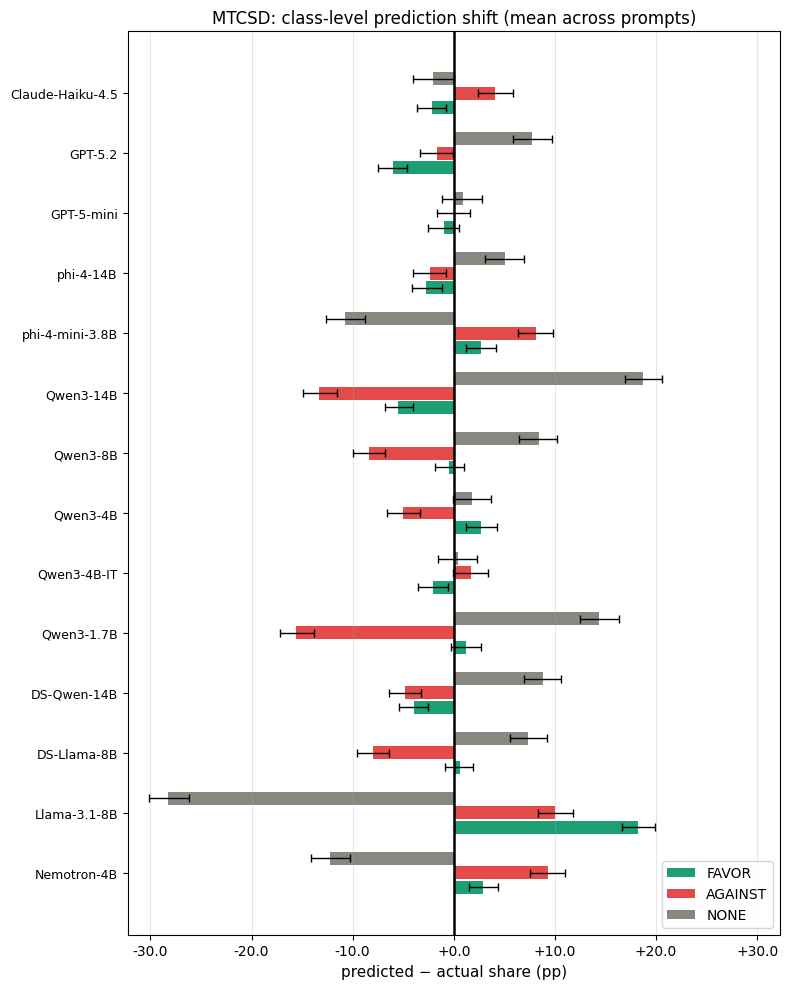

Saved → ../data_out/stance/stance_analysis/marginal_shift_mtcsd_horizontal.png


In [321]:
# ── horizontal-bar alternative (same data/sort as the vertical chart above) ───
# Reuses _ms, _pt, _ci, _LABEL_MAP, _CLR, CLASSES, _DATASET, _OUT from the cell
# above - only the orientation changes, nothing is recomputed.
_bw_h  = 0.24
_off_h = {"FAVOR": _bw_h, "AGAINST": 0.0, "NONE": -_bw_h}
_y     = np.arange(len(_ms))

fig, ax = plt.subplots(figsize=(8, 10))
for _c in CLASSES:
    _h  = [_pt[m][_c] for m in _ms]
    _lo = [_pt[m][_c] - _ci[m][_c][0] for m in _ms]
    _hi = [_ci[m][_c][1] - _pt[m][_c] for m in _ms]
    ax.barh(_y + _off_h[_c], _h, height=_bw_h * 0.9, color=_CLR[_c], label=_c,
            xerr=[_lo, _hi], capsize=3, error_kw=dict(lw=1.0, capthick=1.0))

_xlim = max(abs(_pt[m][c]) + max(abs(_pt[m][c] - _ci[m][c][0]),
                                   abs(_ci[m][c][1] - _pt[m][c]))
            for m in _ms for c in CLASSES) + 2
ax.set_xlim(-_xlim, _xlim)
ax.axvline(0, color="black", linewidth=1.8)
ax.set_yticks(_y)
ax.set_yticklabels(_xl, fontsize=9)
ax.invert_yaxis()  # first model in _ms (Closed group, lead model) ends up at the top
ax.set_xlabel("predicted − actual share (pp)", fontsize=11)
ax.set_title(f"{_DATASET}: class-level prediction shift (mean across prompts)", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.1f}"))
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
_fp_h = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}_horizontal.png"
plt.savefig(_fp_h, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp_h}")

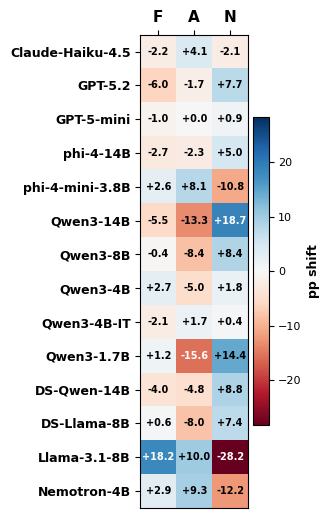

Saved → ../data_out/stance/stance_analysis/marginal_shift_mtcsd_heatmap.png


In [325]:
# ── compact ACL-column heatmap (rows = models, cols = stance classes) ─────────
# blue = overprediction, red = underprediction; 3.3in wide = single ACL column
_hm_data = np.array([[_pt[m][c] for c in CLASSES] for m in _ms])
_xl_short = [_LABEL_MAP.get(m, m) for m in _ms]
_vmax = max(np.abs(_hm_data).max(), 1.0)
_n_models = len(_ms)
_fig_h = max(2.5, _n_models * 0.32 + 0.8)

fig, ax = plt.subplots(figsize=(3.3, _fig_h))
im = ax.imshow(_hm_data, cmap="RdBu", vmin=-_vmax, vmax=_vmax, aspect="auto")

_CLASS_SHORT = {"FAVOR": "F", "AGAINST": "A", "NONE": "N"}
ax.set_xticks(range(len(CLASSES)))
ax.set_xticklabels([_CLASS_SHORT.get(c, c) for c in CLASSES], fontsize=11, fontweight="bold")
ax.set_yticks(range(_n_models))
ax.set_yticklabels(_xl_short, fontsize=9, fontweight="bold")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

for i in range(_n_models):
    for j, _c in enumerate(CLASSES):
        val = _hm_data[i, j]
        color = "white" if abs(val) > _vmax * 0.55 else "black"
        ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                fontsize=7, fontweight="bold", color=color)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.12, pad=0.04)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("pp shift", fontsize=9, fontweight="bold")


plt.tight_layout()
_fp_hm = _OUT / f"marginal_shift_{_DATASET.lower().replace(' ', '_')}_heatmap.png"
plt.savefig(_fp_hm, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {_fp_hm}")

In [323]:
# ── marginal shift table ──────────────────────────────────────────────────────
_rows_tbl = []
for _m in _ms:
    _row = {"Model": _LABEL_MAP.get(_m, _m)}
    for _c in CLASSES:
        lo, hi = _ci[_m][_c]
        _row[_c] = f"{_pt[_m][_c]:+.1f} [{lo:+.1f},{hi:+.1f}]"
    _rows_tbl.append(_row)

_df_tbl = pd.DataFrame(_rows_tbl).set_index("Model")
_df_tbl.columns = ["FAVOR (pp)", "AGAINST (pp)", "NONE (pp)"]

_styled = _df_tbl.style.set_caption(f"{_DATASET}: Marginal Shift per Model (mean ± 95% CI)")\
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "13px"), ("font-weight", "bold"), ("text-align", "left"),
                   ("padding-bottom", "6px")]},
        {"selector": "th",
         "props": [("font-size", "12px"), ("font-weight", "bold"), ("text-align", "center"),
                   ("background-color", "#f0f0f0"), ("padding", "4px 8px")]},
        {"selector": "td",
         "props": [("font-size", "11px"), ("text-align", "center"), ("padding", "3px 8px")]},
        {"selector": "tr:nth-child(even)",
         "props": [("background-color", "#fafafa")]},
    ])\
    .apply(lambda col: [
        "color: #C0392B; font-weight:bold" if float(v.split()[0]) > 0
        else "color: #2471A3; font-weight:bold"
        for v in col
    ], axis=0)

from IPython.display import display
display(_styled)

,FAVOR (pp),AGAINST (pp),NONE (pp)
Model,,,
Claude-Haiku-4.5,"-2.2 [-3.6,-0.7]","+4.1 [+2.4,+5.8]","-2.1 [-4.0,+0.0]"
GPT-5.2,"-6.0 [-7.5,-4.6]","-1.7 [-3.4,-0.1]","+7.7 [+5.8,+9.7]"
GPT-5-mini,"-1.0 [-2.5,+0.5]","+0.0 [-1.7,+1.6]","+0.9 [-1.2,+2.8]"
phi-4-14B,"-2.7 [-4.2,-1.2]","-2.3 [-4.0,-0.8]","+5.0 [+3.1,+7.0]"
phi-4-mini-3.8B,"+2.6 [+1.2,+4.2]","+8.1 [+6.4,+9.9]","-10.8 [-12.7,-8.7]"
Qwen3-14B,"-5.5 [-6.8,-4.1]","-13.3 [-14.9,-11.6]","+18.7 [+16.9,+20.6]"
Qwen3-8B,"-0.4 [-1.9,+1.0]","-8.4 [-10.0,-6.8]","+8.4 [+6.5,+10.2]"
Qwen3-4B,"+2.7 [+1.2,+4.3]","-5.0 [-6.6,-3.4]","+1.8 [-0.1,+3.6]"
Qwen3-4B-IT,"-2.1 [-3.5,-0.6]","+1.7 [-0.1,+3.4]","+0.4 [-1.6,+2.3]"


In [324]:
# ── Appendix tables: MTCSD — 3-class Macro F1 + 2-class F_avg ───────────────
from IPython.display import display, HTML
import pandas as pd

_SHORT_NAME = {
    'Qwen3-1.7B':'Qwen3-1.7B','Qwen3-4B':'Qwen3-4B','Qwen3-4B-Instruct-2507':'Qwen3-4B-IT',
    'Qwen3-8B':'Qwen3-8B','Qwen3-14B':'Qwen3-14B',
    'DeepSeek-R1-Distill-Llama-8B':'DS-Llama-8B','DeepSeek-R1-Distill-Qwen-14B':'DS-Qwen-14B',
    'Llama-3.1-8B-Instruct':'Llama-3.1-8B','phi-4':'Phi-4','phi-4-mini-instruct':'Phi-4-mini',
    'Nemotron-Mini-4B-Instruct':'Nemotron-4B',
    'gpt-5-mini':'GPT-5-mini †','gpt-5.2':'GPT-5.2 †','claude-haiku-4-5-20251001':'Haiku-4.5 †',
}
_FAMILY = {
    'Qwen3-1.7B':'Qwen3','Qwen3-4B':'Qwen3','Qwen3-4B-Instruct-2507':'Qwen3',
    'Qwen3-8B':'Qwen3','Qwen3-14B':'Qwen3',
    'DeepSeek-R1-Distill-Llama-8B':'DeepSeek','DeepSeek-R1-Distill-Qwen-14B':'DeepSeek',
    'Llama-3.1-8B-Instruct':'Llama','phi-4':'Phi','phi-4-mini-instruct':'Phi',
    'Nemotron-Mini-4B-Instruct':'Nemotron',
    'gpt-5-mini':'Closed','gpt-5.2':'Closed','claude-haiku-4-5-20251001':'Closed',
}
_FAMILY_ORDER = ['Qwen3','DeepSeek','Llama','Phi','Nemotron','Closed']
_SIZE = {
    'Qwen3-1.7B':1.7,'Qwen3-4B':4,'Qwen3-4B-Instruct-2507':4.1,'Qwen3-8B':8,'Qwen3-14B':14,
    'DeepSeek-R1-Distill-Llama-8B':8,'DeepSeek-R1-Distill-Qwen-14B':14,
    'Llama-3.1-8B-Instruct':8,'phi-4':14,'phi-4-mini-instruct':3.8,
    'Nemotron-Mini-4B-Instruct':4,'gpt-5-mini':100,'gpt-5.2':101,'claude-haiku-4-5-20251001':102,
}
def _model_sort(m):
    fam = _FAMILY.get(m,'Other')
    fi  = _FAMILY_ORDER.index(fam) if fam in _FAMILY_ORDER else 99
    return (fi, _SIZE.get(m,0))

def _render_table(df_src, metric_col, prompt_order, prompt_labels, title,
                  baselines=None, exclude_prefix=None):
    from IPython.display import display, HTML
    import pandas as pd

    _df = df_src.copy()
    if exclude_prefix:
        _df = _df[~_df['prompt'].str.startswith(exclude_prefix)]
    _prompts = [p for p in prompt_order if p in _df['prompt'].unique()]
    _df = _df[_df['prompt'].isin(_prompts)]

    _pivot = _df.pivot_table(index='model', columns='prompt',
                             values=metric_col, aggfunc='mean')
    _pivot = _pivot.reindex(columns=[p for p in _prompts if p in _pivot.columns])
    _pivot.columns = [prompt_labels.get(c,c) for c in _pivot.columns]
    _pivot = _pivot.loc[sorted(_pivot.index, key=_model_sort)]
    _pivot.index = [_SHORT_NAME.get(m,m) for m in _pivot.index]

    _all_vals = list(_pivot.values.flatten())
    if baselines:
        _all_vals += [v for _,v in baselines]
    _best = max(x for x in _all_vals if not pd.isna(x))

    def _fmt(v, bold=True):
        if pd.isna(v): return '—'
        s = f'{v:.3f}'
        return f'<b>{s}</b>' if (bold and abs(v - _best) < 1e-5) else s

    ncols = len(_pivot.columns)
    th = lambda t, extra='': f'<th style="text-align:center;padding:3px 7px;font-size:10px;background:#f0f0f0{extra}">{t}</th>'

    col_hdrs = ''.join(th(c) for c in _pivot.columns)
    rows_html = []

    # ── baseline rows ──────────────────────────────────────────────────────────
    if baselines:
        rows_html.append(
            f'<tr><td colspan="{ncols+1}" style="background:#fff3cd;font-weight:bold;'
            f'font-style:italic;font-size:10px;padding:2px 8px">Supervised Baseline</td></tr>')
        for bname, bval in baselines:
            bcells = ''.join(
                f'<td style="text-align:center;padding:2px 7px;font-size:10px;'
                f'background:#fffbea">{_fmt(bval)}</td>' for _ in _pivot.columns)
            rows_html.append(
                f'<tr style="border-bottom:1px solid #ccc">'
                f'<td style="padding:2px 8px;font-size:10px;white-space:nowrap;'
                f'background:#fffbea"><i>{bname}</i></td>{bcells}</tr>')

    # ── model rows ─────────────────────────────────────────────────────────────
    _prev_fam = None
    for _mname, _row in _pivot.iterrows():
        _orig = next((k for k,v in _SHORT_NAME.items() if v==_mname), _mname)
        _fam  = _FAMILY.get(_orig,'Other')
        if _fam != _prev_fam:
            rows_html.append(
                f'<tr><td colspan="{ncols+1}" style="background:#e8e8e8;font-weight:bold;'
                f'font-style:italic;font-size:10px;padding:2px 8px">{_fam}</td></tr>')
            _prev_fam = _fam
        _cells = ''.join(
            f'<td style="text-align:center;padding:2px 7px;font-size:10px">{_fmt(_row[c])}</td>'
            for c in _pivot.columns)
        rows_html.append(
            f'<tr><td style="padding:2px 8px;font-size:10px;white-space:nowrap">{_mname}</td>{_cells}</tr>')

    html = (
        f'<table style="border-collapse:collapse;margin-bottom:24px">'
        f'<caption style="font-weight:bold;font-size:12px;text-align:left;padding-bottom:6px">{title}</caption>'
        f'<thead><tr style="border-top:2px solid #333;border-bottom:1px solid #888">'
        f'<th style="text-align:left;padding:3px 8px;font-size:10px">Model</th>{col_hdrs}</tr></thead>'
        f'<tbody>{"".join(rows_html)}</tbody>'
        f'<tfoot><tr><td colspan="{ncols+1}" style="font-size:9px;color:#666;padding:4px 8px;'
        f'border-top:1px solid #aaa">† Closed model (API). <b>Bold</b> = highest score in table.</td></tr></tfoot>'
        f'</table>'
    )
    display(HTML(html))
    print(_pivot.to_string(float_format='{:.3f}'.format))
    print()

# Table 1: 3-class Macro F1 (no supervised baseline for 3-class in MTCSD paper)
_render_table(
    df_src       = llm_df,
    metric_col   = '3class_macro_f1',
    prompt_order = PROMPT_ORDER,
    prompt_labels= PROMPT_LABELS,
    title        = 'MTCSD — 3-class Macro F1 per model × prompt',
    baselines    = None,
)

# Table 2: 2-class F_avg with KPT baseline
_KPT_FAVG = 42.34 / 100   # mean across 5 targets, excl. Post-T (MT²-CSD Table IX)
_render_table(
    df_src       = llm_df,
    metric_col   = 'f_avg',
    prompt_order = PROMPT_ORDER,
    prompt_labels= PROMPT_LABELS,
    title        = 'MTCSD — 2-class Fₐᵥᵶ (FAVOR+AGAINST) per model × prompt',
    baselines    = [('KPT individual posts (MT²-CSD paper)', _KPT_FAVG)],
)

              No-def  Default  Task-def  Question   CoT  Scale    3R    6R    9R   12R   15R
Qwen3-1.7B     0.420    0.424     0.438     0.455 0.530  0.487 0.452 0.457 0.486 0.495 0.452
Qwen3-4B       0.498    0.520     0.549     0.540 0.542  0.547 0.569 0.568 0.554 0.551 0.567
Qwen3-4B-IT    0.541    0.524     0.556     0.537 0.549  0.514 0.551 0.544 0.554 0.552 0.554
Qwen3-8B       0.500    0.507     0.533     0.547 0.535  0.566 0.558 0.570 0.569 0.566 0.577
Qwen3-14B      0.522    0.516     0.545     0.565 0.540  0.561 0.546 0.543 0.570 0.572 0.572
DS-Llama-8B    0.525    0.520     0.529     0.549 0.557  0.539 0.541 0.552 0.553 0.553 0.545
DS-Qwen-14B    0.577    0.565     0.570     0.580 0.571  0.576 0.567 0.571 0.588 0.581 0.575
Llama-3.1-8B   0.533    0.538     0.472     0.464 0.475  0.469 0.400 0.415 0.371 0.404 0.431
Phi-4-mini     0.527    0.541     0.543     0.521 0.495  0.527 0.509 0.524 0.502 0.503 0.514
Phi-4          0.566    0.551     0.581     0.552 0.567  0.549 0.574 0

              No-def  Default  Task-def  Question   CoT  Scale    3R    6R    9R   12R   15R
Qwen3-1.7B     0.330    0.306     0.308     0.355 0.400  0.425 0.254 0.252 0.315 0.340 0.319
Qwen3-4B       0.387    0.379     0.408     0.451 0.437  0.422 0.448 0.453 0.445 0.433 0.459
Qwen3-4B-IT    0.405    0.373     0.443     0.459 0.425  0.407 0.442 0.448 0.466 0.463 0.460
Qwen3-8B       0.365    0.349     0.388     0.430 0.405  0.452 0.424 0.460 0.458 0.462 0.469
Qwen3-14B      0.377    0.357     0.384     0.429 0.392  0.431 0.387 0.390 0.427 0.433 0.431
DS-Llama-8B    0.427    0.404     0.406     0.439 0.453  0.455 0.405 0.424 0.428 0.430 0.431
DS-Qwen-14B    0.451    0.434     0.444     0.466 0.466  0.491 0.425 0.433 0.460 0.459 0.450
Llama-3.1-8B   0.450    0.454     0.464     0.464 0.447  0.443 0.413 0.418 0.406 0.428 0.439
Phi-4-mini     0.453    0.432     0.451     0.449 0.444  0.463 0.437 0.455 0.434 0.438 0.438
Phi-4          0.440    0.410     0.451     0.484 0.455  0.482 0.449 0